# POCAL — Optical Coating Analysis Library

### A guided tour with worked examples

POCAL (**P**ython **O**ptical **C**oating **A**nalysis **L**ibrary) computes the optical
response of thin-film multilayer stacks using the characteristic-matrix method, with no
approximations. This notebook works through every feature of the library on real designs.

**Reference:** T. Fontanot, U. Bhaumik, R. Kishore, Y. Meuret,
*"POCAL: a Python-based library to perform optical coating analysis and design"*,
Optics Continuum **2**(4), 810 (2023). [doi:10.1364/OPTCON.484972](https://doi.org/10.1364/OPTCON.484972)

---

## What this notebook covers

| # | Section | Feature |
|---|---------|---------|
| 1 | Setup | Installation, resources, helper functions |
| 2 | Prescription files | Input format, stack diagrams |
| 3 | Material library | Refractive index data, adding your own materials |
| 4 | Reflectance, transmittance, absorbance | The core calculation |
| 5 | Angle and polarization | s vs p, Brewster's angle, angle maps |
| 6 | Antireflection coatings | Optical thickness mode, single and two layer |
| 7 | Bragg mirrors | Quarter-wave stacks, stopband engineering |
| 8 | Metallic and absorbing films | Silver mirrors, energy conservation |
| 9 | Phase, group delay, GDD | Dispersion of the coating |
| 10 | Admittance diagrams | Graphical design technique |
| 11 | Electric field | Standing waves inside the stack |
| 12 | Colour analysis | CIE tristimulus, chromaticity |
| 13 | Refinement | Automatic thickness optimization |
| 14 | Validation | Checks against closed-form physics |
| 15 | Quick reference | API summary |


---
# 1. Setup

## 1.1 Install

POCAL is on PyPI. The `2.449` release or later is recommended — earlier versions had a bug in
the substrate incidence-angle bookkeeping that made all off-normal results slightly wrong.


In [1]:
!pip install --upgrade "pocal>=2.449"


## 1.2 Supporting files

POCAL reads several data files **from the current working directory**:

| File | Needed for |
|------|-----------|
| `materialLibrary.json` | always — refractive index data |
| `cmf1931.txt`, `cmf1964.txt` | colour analysis — standard observers |
| `a.txt`, `d65.txt`, `e.txt` | colour analysis — illuminants |
| `CIE.png` | colour analysis — chromaticity diagram image |
| `target.txt` | refinement — optimization goal |

All of them live in the [`resources`](https://github.com/tommasofontanot/pocal/tree/main/resources)
folder of the repository. The cell below fetches them if they aren't already present.


In [2]:
import os, io, zipfile, urllib.request

if not os.path.exists('materialLibrary.json'):
    url = 'https://github.com/tommasofontanot/pocal/archive/refs/heads/main.zip'
    print('Downloading resources...')
    with urllib.request.urlopen(url) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    for name in z.namelist():
        if '/resources/' in name and not name.endswith('/'):
            with open(os.path.basename(name), 'wb') as fh:
                fh.write(z.read(name))
    print('Done.')

print('Working directory:', os.getcwd())
print('Found:', sorted(f for f in os.listdir('.') if f.endswith(('.json', '.txt', '.png')))[:12])


Done.
Working directory: /content
Found: ['3layers.txt', 'CIE.png', 'GD_trans.png', 'GD_trans.txt', 'LICENSE.txt', 'a.txt', 'absorbance.png', 'absorbance.txt', 'c.txt', 'cmf1931.txt', 'cmf1964.txt', 'd65.txt']


## 1.3 Imports and plotting style

POCAL draws its own figures. For side-by-side comparisons we also pull the raw numbers out of
the return values, so the helper below runs a calculation and **suppresses** the automatic plot.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import json

import pocal

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (7, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 100,
})


def spectrum(prescription, angle=0, quantity='reflectance', pol='s',
             lo=400, hi=800, step=2, ref=550, optical=False):
    """Run POCAL and return (wavelength, value) arrays without drawing its plot.

    quantity: 'reflectance' | 'transmittance' | 'absorbance'
    pol:      's' | 'p'
    optical:  True if the prescription lists optical thickness (fraction of ref wavelength)
    """
    stack = pocal.pocal(prescription, angle, lo, hi, step, ref, optical, None)
    fn = stack.s_polarization if pol == 's' else stack.p_polarization
    w, v = fn(quantity, savefile=False, savefig=False)
    plt.close('all')          # discard POCAL's own figure
    return np.array(w).ravel(), np.array(v).ravel()


def write_stack(filename, layers):
    """Write a prescription file. layers = [(material, thickness), ...]"""
    with open(filename, 'w') as fh:
        for material, thickness in layers:
            fh.write(f'{material}\t{thickness}\n')
    return filename


print('POCAL ready.')


POCAL ready.


---
# 2. The prescription file

Every POCAL calculation starts from a two-column text file:

```
Glass    0      <- incident (immersing) medium
SiO2     50     <- outermost layer
TiO2     60
SiO2     70     <- layer closest to substrate
Glass    0      <- substrate
```

**Order matters.** First line is the medium the light arrives from, last line is the substrate,
and layers run outermost → innermost in between. Medium and substrate are treated as
semi-infinite, so their thickness is ignored — but a number must still be present.

The second column is either **physical thickness in nm** (`opt_thick=False`) or **optical
thickness as a fraction of the reference wavelength** (`opt_thick=True`), where 0.25 means a
quarter-wave layer.

## 2.1 Calling the library

```python
stack = pocal.pocal(prescription,   # path to the file above
                    angle_in_deg,   # incidence angle inside the medium
                    min_wave,       # nm
                    max_wave,       # nm
                    resolution,     # nm between sample points
                    ref_wave,       # reference wavelength, nm
                    opt_thick,      # True = optical thickness, False = physical nm
                    refinement_type)# None | 'reflectance' | 'transmittance'
```


In [5]:
# The three-layer design from the paper (Fig. 1)
three_layer = write_stack('3layer_demo.txt', [
    ('Glass', 0),     # medium
    ('SiO2', 50),     # layer 3
    ('TiO2', 60),     # layer 2
    ('SiO2', 70),     # layer 1
    ('Glass', 0),     # substrate
])

print(open(three_layer).read())


Glass	0
SiO2	50
TiO2	60
SiO2	70
Glass	0



## 2.2 Visualising the stack

A quick diagram makes designs much easier to sanity-check. This helper reads any prescription
file and draws it to scale.


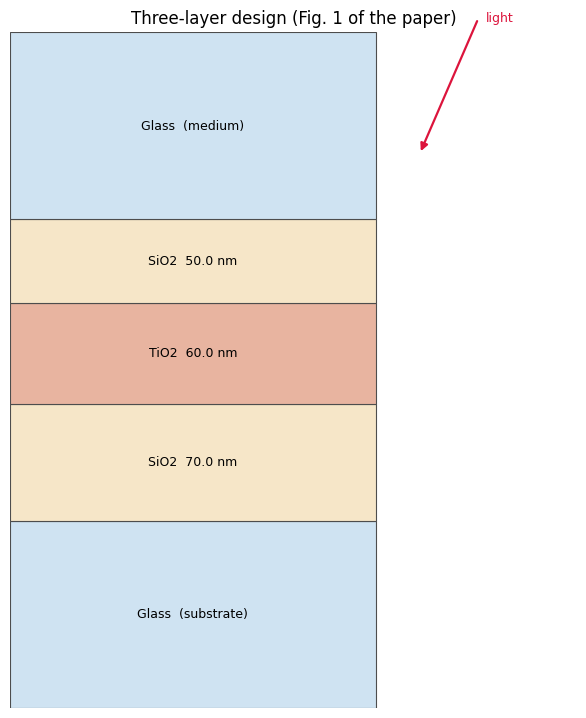

In [6]:
COLOURS = {'Air': '#eef4fb', 'Glass': '#cfe3f2', 'SiO2': '#f6e6c8', 'TiO2': '#e8b4a0',
           'MgF2': '#dff0e0', 'Ta2O5': '#d8bfe0', 'Al2O3': '#f0d9d9', 'HfO2': '#c9d9c0',
           'Ag': '#d9d9d9', 'Al': '#c8ccd0', 'ZrO2': '#e3d4b8', 'Y2O3': '#cfe0d8',
           'Na3AlF6': '#eaf2ea'}


def draw_stack(prescription, ref_wave=550, optical=False, ax=None, title=None):
    """Draw a cross-section of a prescription file, layers to scale."""
    rows = [line.split() for line in open(prescription) if line.strip()]
    materials = [r[0] for r in rows]
    thickness = [float(r[1]) for r in rows]

    if optical:   # convert to nm for drawing, using n at the reference wavelength
        probe = pocal.pocal(prescription, 0, ref_wave - 10, ref_wave + 10, 10,
                            ref_wave, False, None)
        thickness = [t * ref_wave / probe.search_from_nr_k_generator(probe.nr_k_array, m)[0]
                     [probe.wave_spacing == ref_wave][0] for m, t in zip(materials, thickness)]

    inner = thickness[1:-1]
    cap = max(inner) * 1.6 if inner else 100      # drawn height of medium/substrate
    heights = [cap] + inner + [cap]

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 0.35 * sum(heights) / max(heights) * len(heights) + 1))

    y = 0
    for material, h in zip(reversed(materials), reversed(heights)):
        ax.add_patch(Rectangle((0, y), 1, h, facecolor=COLOURS.get(material, '#dddddd'),
                               edgecolor='0.3', lw=0.8))
        y += h

    y = 0
    for i, (material, h) in enumerate(zip(reversed(materials), reversed(heights))):
        idx = len(materials) - 1 - i
        if idx == 0:
            label = f'{material}  (medium)'
        elif idx == len(materials) - 1:
            label = f'{material}  (substrate)'
        else:
            label = f'{material}  {thickness[idx]:.1f} nm'
        ax.text(0.5, y + h / 2, label, ha='center', va='center', fontsize=9)
        y += h

    ax.annotate('', xy=(1.12, sum(heights) * 0.82), xytext=(1.28, sum(heights) * 1.02),
                arrowprops=dict(arrowstyle='-|>', color='crimson', lw=1.6))
    ax.text(1.30, sum(heights) * 1.02, 'light', color='crimson', fontsize=9, va='center')

    ax.set_xlim(0, 1.55)
    ax.set_ylim(0, sum(heights))
    ax.axis('off')
    ax.set_title(title or prescription)
    return ax


draw_stack(three_layer, title='Three-layer design (Fig. 1 of the paper)')
plt.tight_layout()
plt.show()


---
# 3. The material library

Optical constants live in `materialLibrary.json`. Each entry is the complex refractive index

$$N = n - jk$$

sampled on a wavelength grid. POCAL splines these onto whatever grid you request; if you ask
for wavelengths beyond the tabulated range it holds the end value constant.

## 3.1 What's in the box


In [7]:
with open('materialLibrary.json') as fh:
    library = json.load(fh)

print(f"{'Material':<10} {'points':>7} {'range (nm)':>18}   {'absorbing?':>10}")
print('-' * 52)
for entry in library:
    wl = entry['wavelength']
    absorbing = 'yes' if max(entry['complex']) > 1e-4 else 'no'
    print(f"{entry['material']:<10} {len(wl):>7} {wl[0]:>8.0f} - {wl[-1]:<8.0f} {absorbing:>10}")


Material    points         range (nm)   absorbing?
----------------------------------------------------
Ag              60      200 - 12000           yes
Al              44       48 - 12000           yes
Al2O3           27      250 - 900              no
HfO2            52      250 - 888              no
MgF2            26      250 - 875              no
Na3AlF6          3      300 - 3000             no
SiO2           449        1 - 500000          yes
Ta2O5            7      250 - 2000            yes
TiO2            24      361 - 1000            yes
Y2O3            24      326 - 715             yes
ZrO2            36      320 - 800             yes
Glass           24      300 - 2325             no
Air             24      300 - 2325             no


## 3.2 Dispersion curves

The dielectrics are transparent across the visible ($k \approx 0$); the metals are strongly
absorbing. Note how much higher TiO₂ sits than SiO₂ — that index contrast is what makes
multilayer mirrors work.


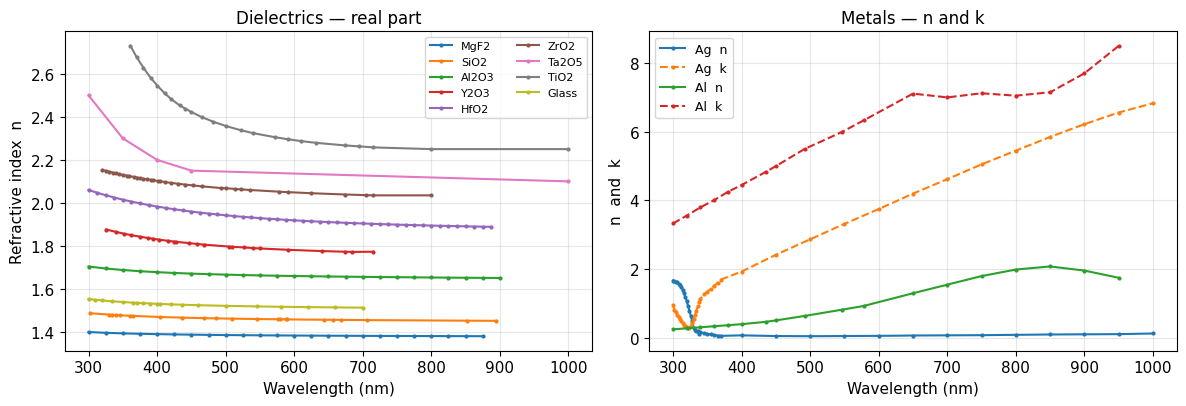

In [8]:
dielectrics = ['MgF2', 'SiO2', 'Al2O3', 'Y2O3', 'HfO2', 'ZrO2', 'Ta2O5', 'TiO2', 'Glass']
metals = ['Ag', 'Al']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for name in dielectrics:
    e = [x for x in library if x['material'] == name][0]
    wl = np.array(e['wavelength']); n = np.array(e['real'])
    m = (wl >= 300) & (wl <= 1000)
    ax1.plot(wl[m], n[m], marker='.', ms=4, label=name)
ax1.set(xlabel='Wavelength (nm)', ylabel='Refractive index  n',
        title='Dielectrics — real part')
ax1.legend(fontsize=8, ncol=2)

for name in metals:
    e = [x for x in library if x['material'] == name][0]
    wl = np.array(e['wavelength'])
    m = (wl >= 300) & (wl <= 1000)
    ax2.plot(wl[m], np.array(e['real'])[m], marker='.', ms=4, label=f'{name}  n')
    ax2.plot(wl[m], np.array(e['complex'])[m], '--', marker='.', ms=4, label=f'{name}  k')
ax2.set(xlabel='Wavelength (nm)', ylabel='n  and  k', title='Metals — n and k')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 3.3 Adding your own material

Append a dictionary with matching-length lists, sorted by increasing wavelength:

```python
{"material": "MyFilm",
 "wavelength": [400, 500, 600, 700],
 "real":       [2.10, 2.05, 2.02, 2.00],
 "complex":    [0.00, 0.00, 0.00, 0.00]}
```

Below we add a fictitious high-index film and use it immediately.


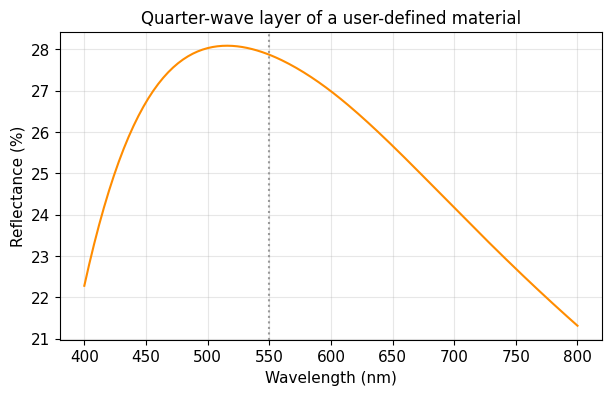

In [9]:
if not any(e['material'] == 'DemoHigh' for e in library):
    library.append({'material': 'DemoHigh',
                    'wavelength': [300, 400, 500, 600, 700, 800, 900],
                    'real':       [2.45, 2.32, 2.24, 2.20, 2.17, 2.15, 2.14],
                    'complex':    [0.0] * 7})
    with open('materialLibrary.json', 'w') as fh:
        json.dump(library, fh, indent=1)

demo = write_stack('demo_material.txt', [('Air', 0), ('DemoHigh', 0.25), ('Glass', 0)])
w, R = spectrum(demo, optical=True, ref=550)

plt.plot(w, R, color='darkorange')
plt.axvline(550, color='0.6', ls=':')
plt.title('Quarter-wave layer of a user-defined material')
plt.xlabel('Wavelength (nm)'); plt.ylabel('Reflectance (%)')
plt.show()


---
# 4. Reflectance, transmittance, absorbance

This is the core of the library. Each layer is represented by its characteristic matrix

$$\begin{pmatrix}\cos\delta_i & \dfrac{j\sin\delta_i}{\eta_i}\\[2mm]
j\eta_i\sin\delta_i & \cos\delta_i\end{pmatrix},
\qquad \delta_i=\frac{2\pi N_i d_i\cos\theta_i}{\lambda}$$

with optical admittances

$$\eta_i = \xi N_i\cos\theta_i \;(\text{s-pol}), \qquad
\eta_i = \frac{\xi N_i}{\cos\theta_i}\;(\text{p-pol}).$$

Multiplying the layer matrices and applying the substrate vector gives $B$ and $C$, from which

$$R=\left(\frac{\eta_0B-C}{\eta_0B+C}\right)\left(\frac{\eta_0B-C}{\eta_0B+C}\right)^{\!*},
\qquad T=\frac{4\eta_0\,\mathrm{Re}(\eta_{sub})}{(\eta_0B+C)(\eta_0B+C)^*}.$$

## 4.1 The built-in plots

The two arguments are `savefile` and `savefig` — set them to `True` to write a `.txt` of the
numbers and a `.png` of the figure.


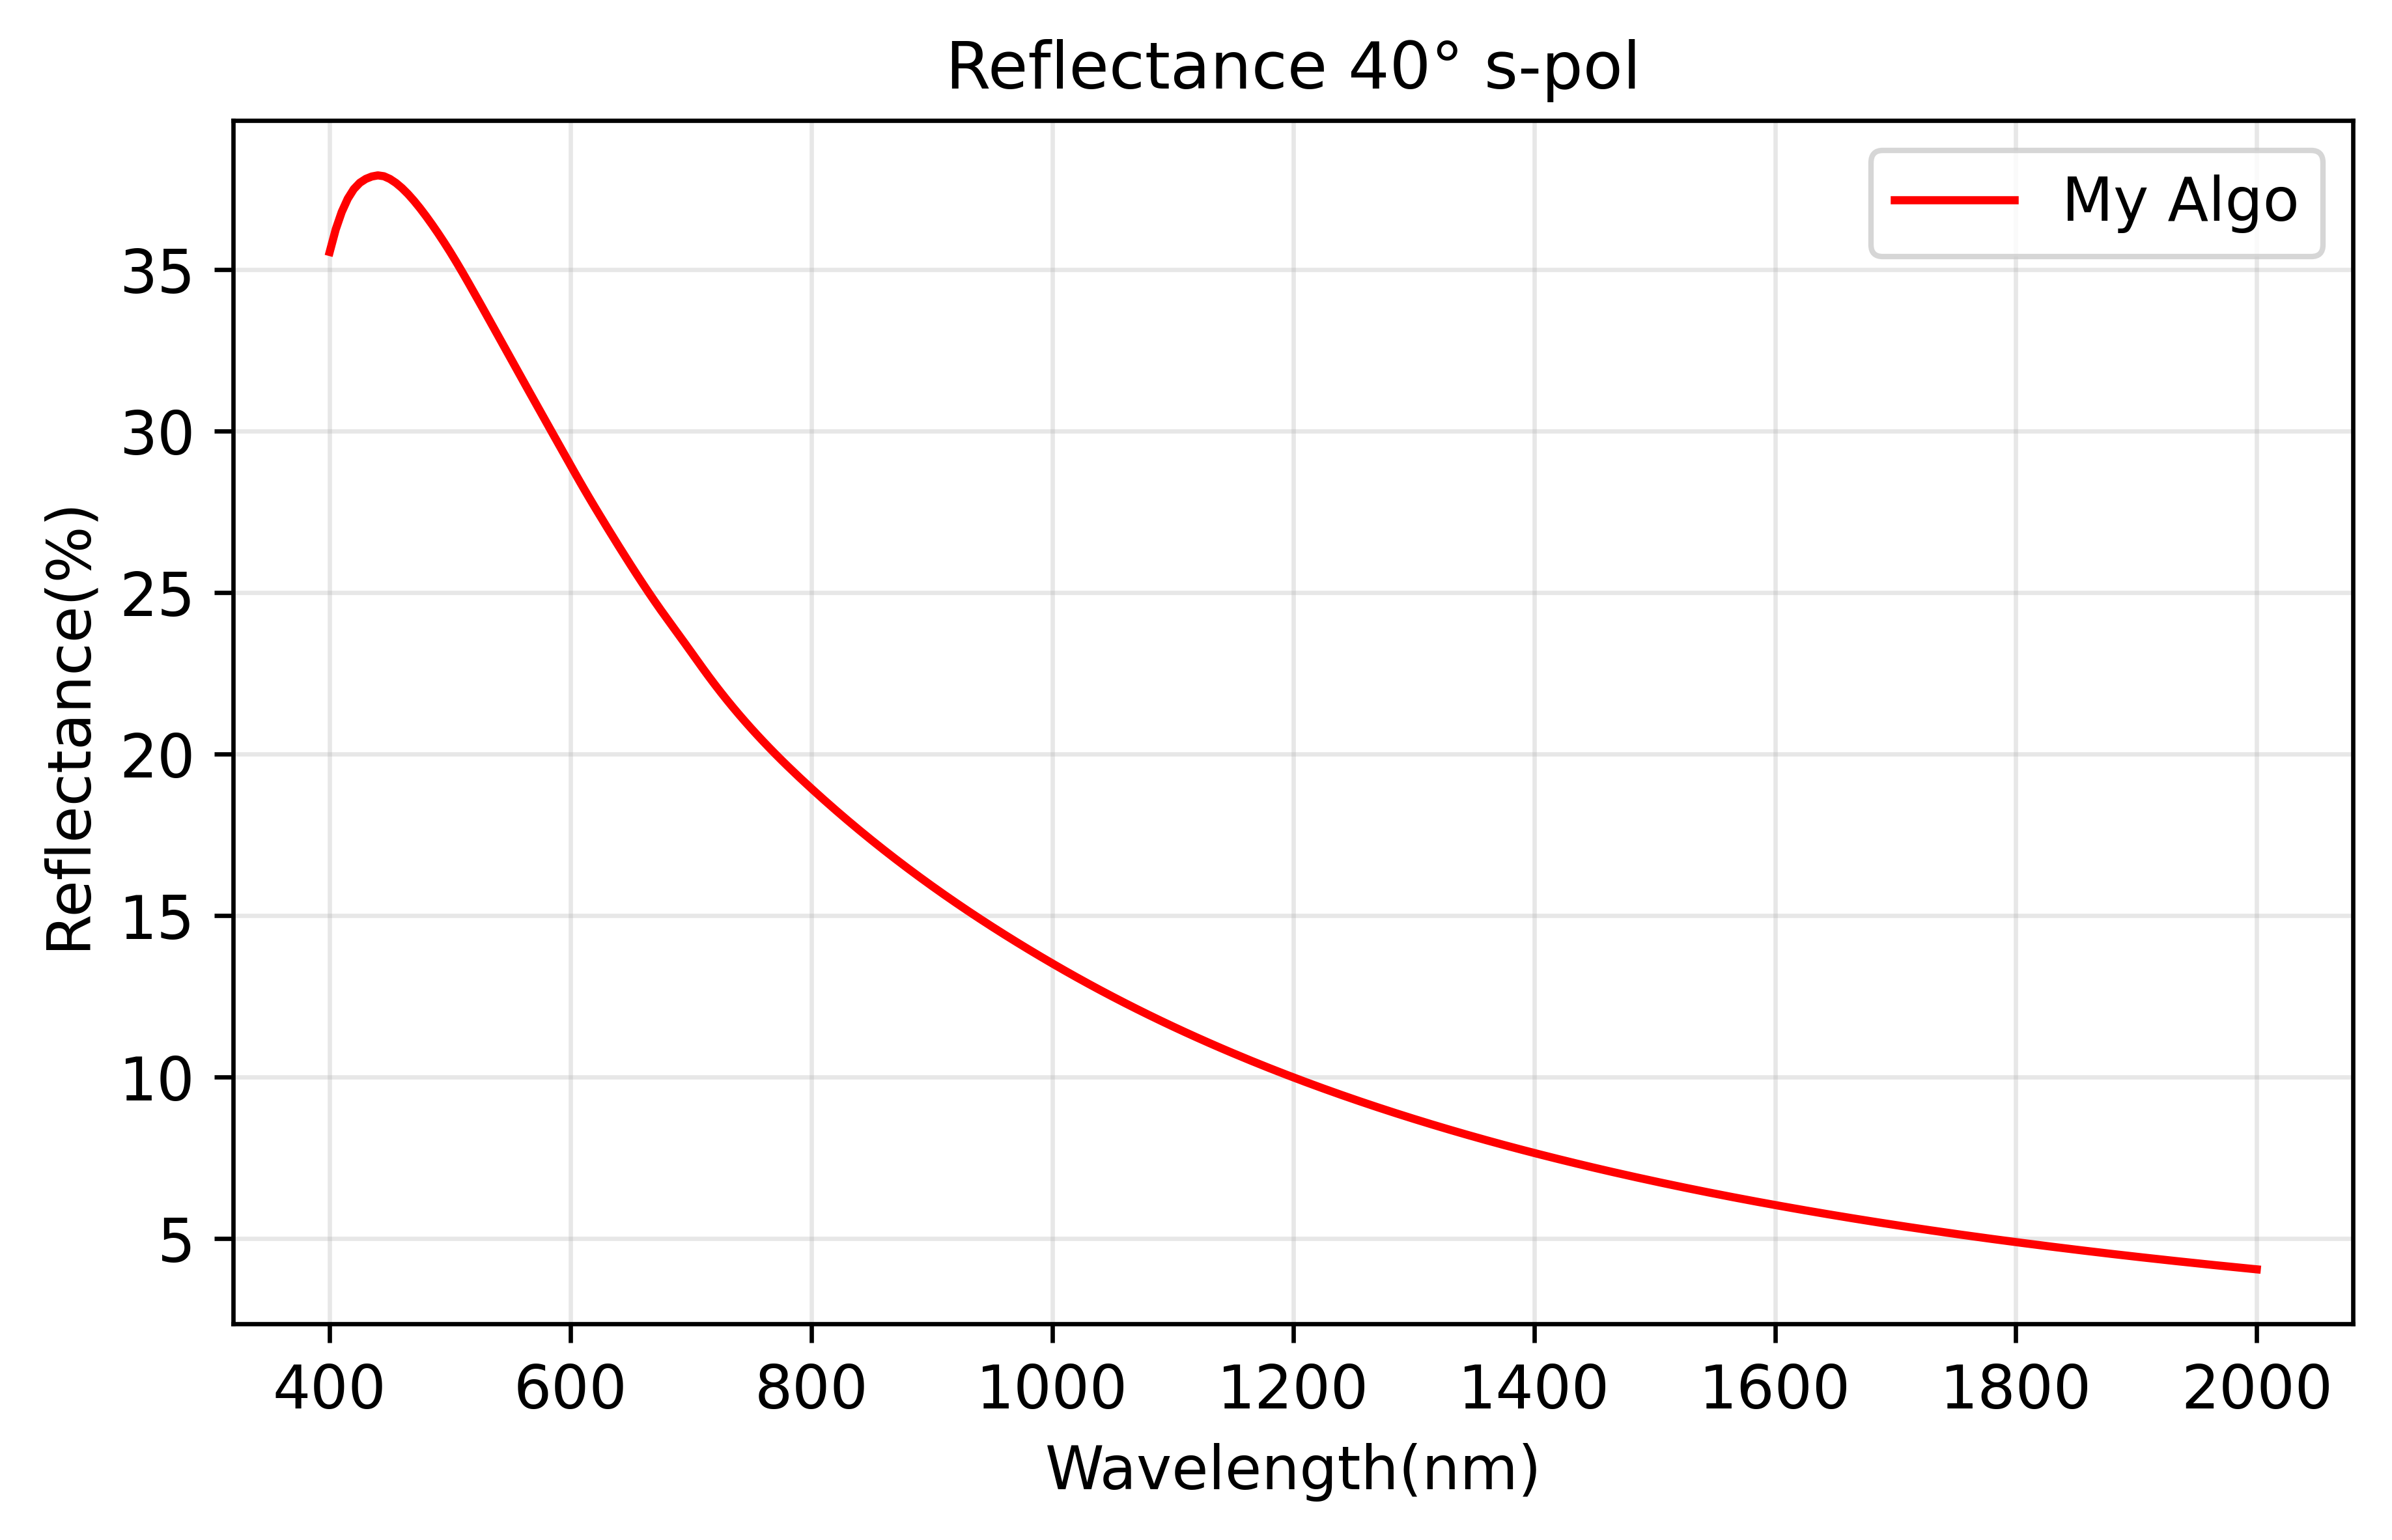

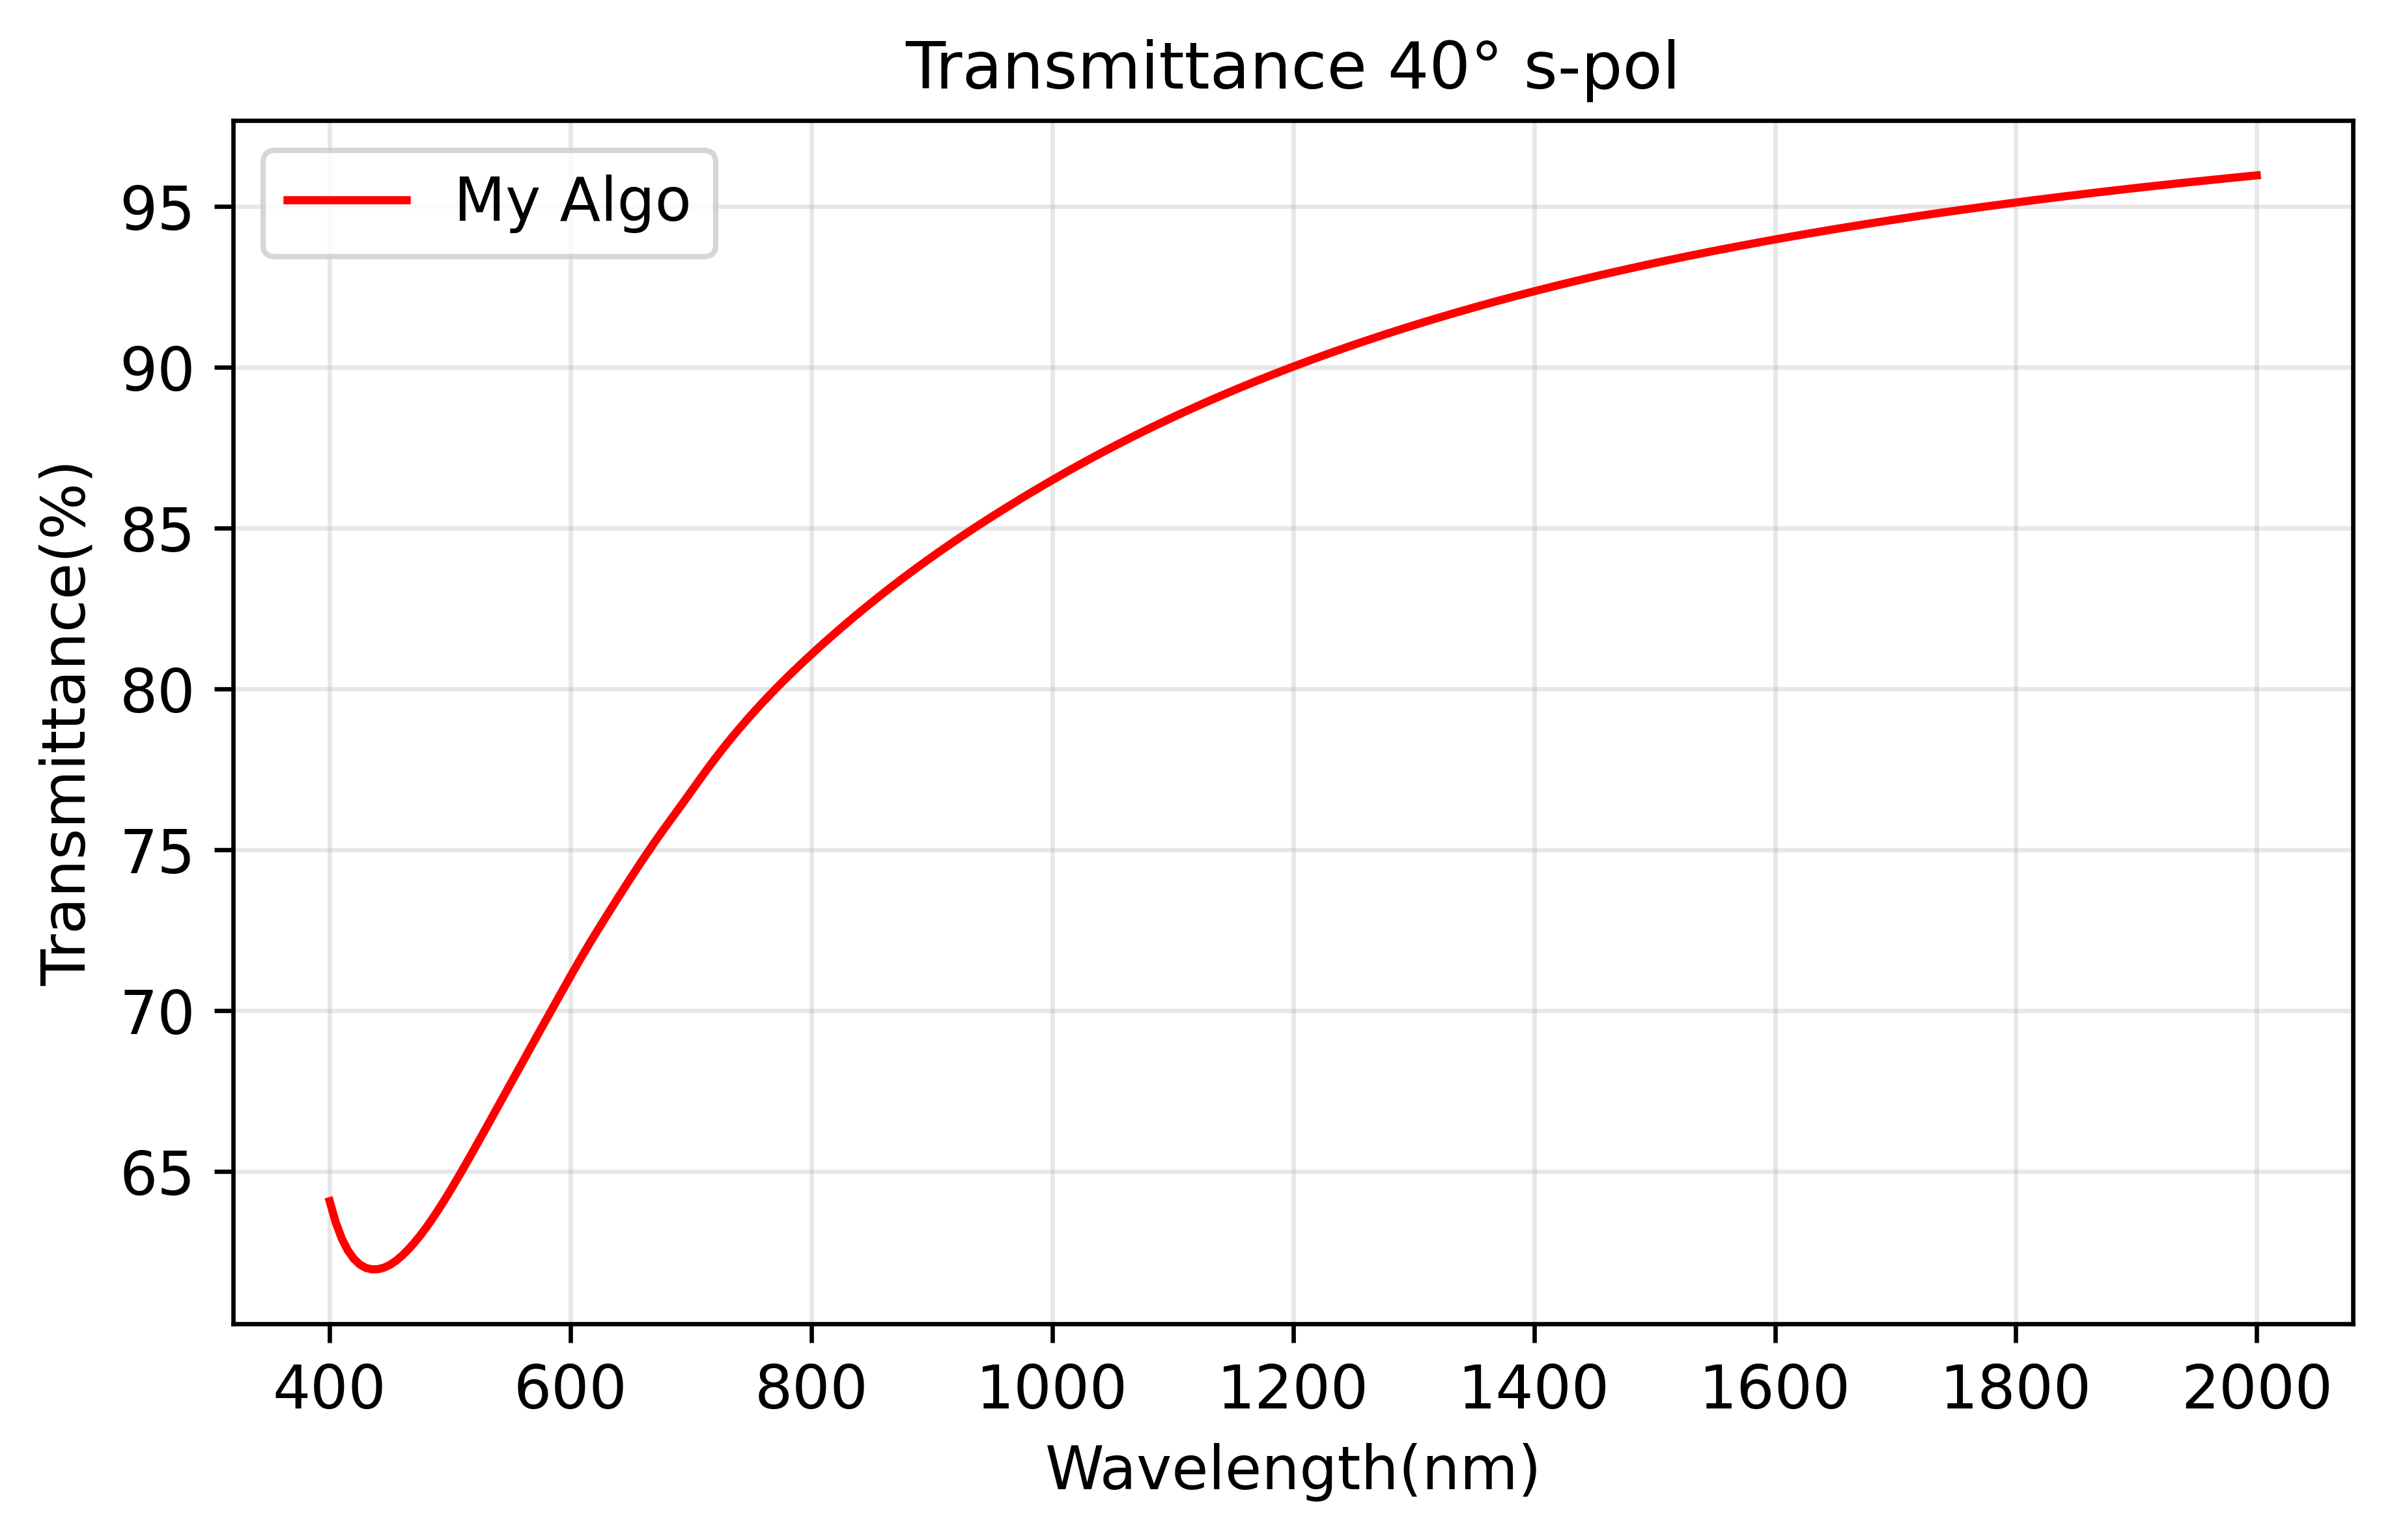

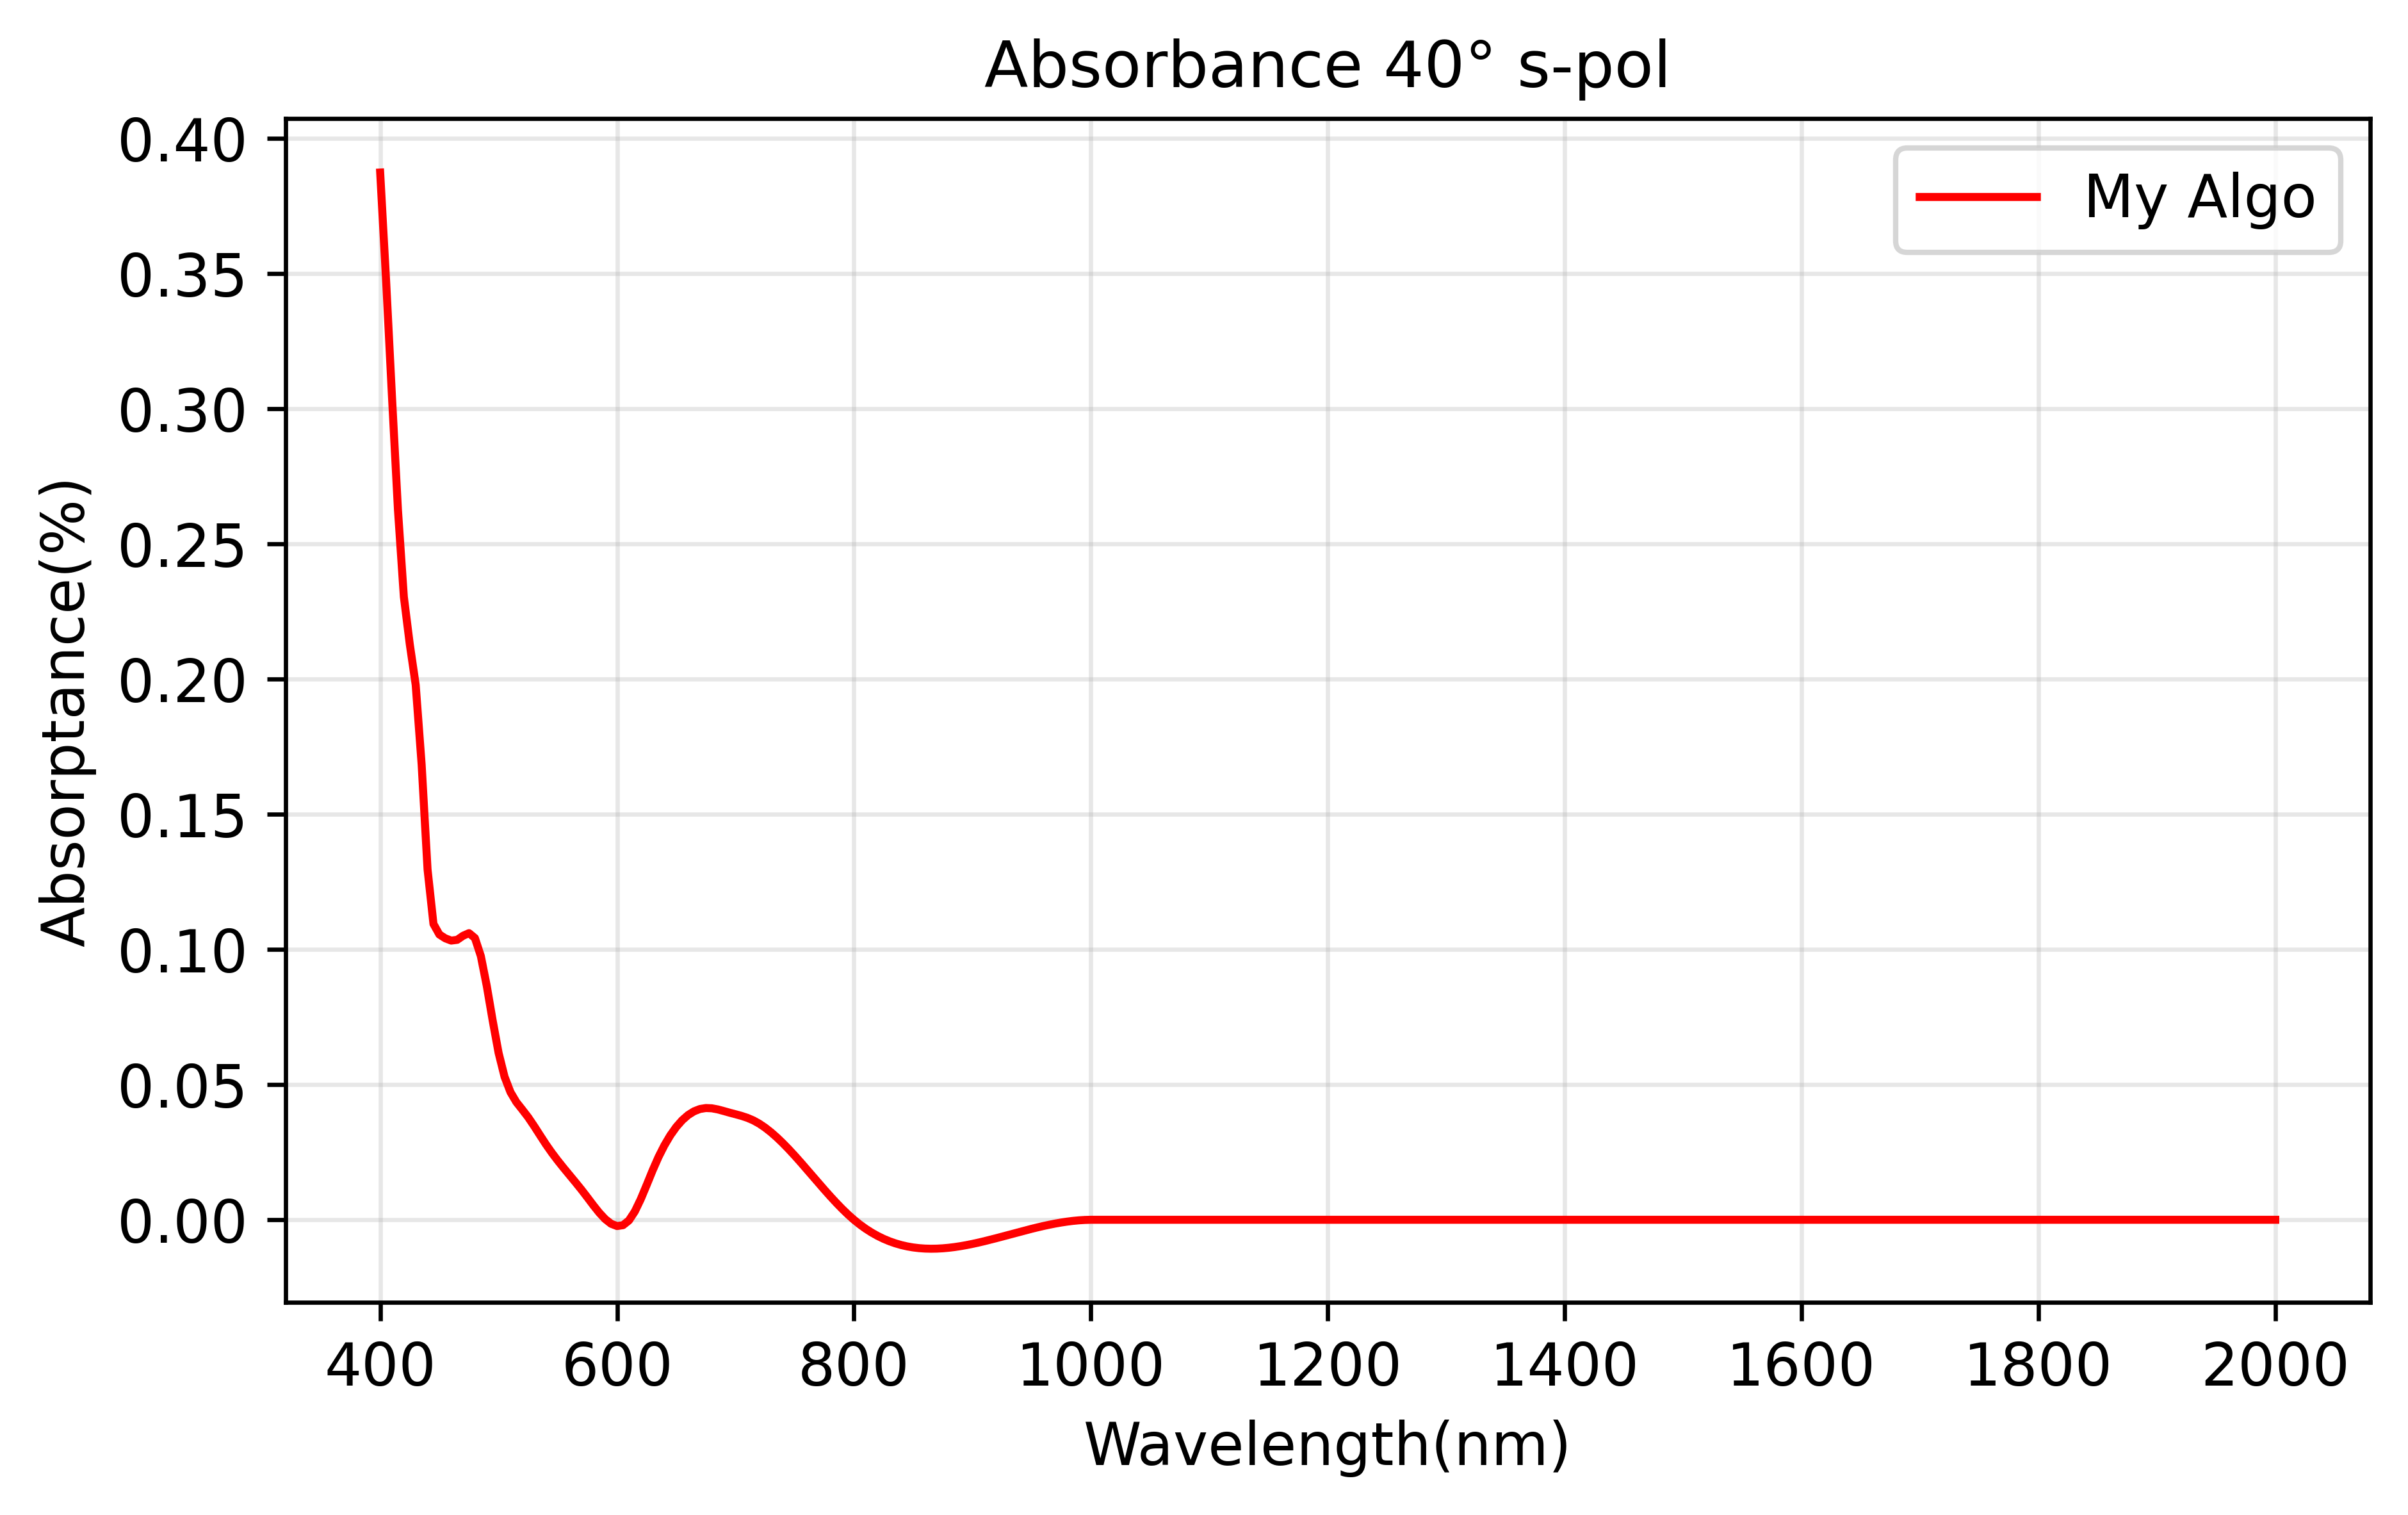

In [10]:
stack = pocal.pocal(three_layer, 40, 400, 2000, 5, 600, False, None)

stack.s_polarization('reflectance', False, False)
stack.s_polarization('transmittance', False, False)
stack.s_polarization('absorbance', False, False)
plt.show()


## 4.2 s and p side by side

Reproducing Fig. 2 of the paper: the same design at 40° incidence, both polarizations.
At normal incidence the two are identical — the distinction only appears off-axis.


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)

for col, pol in enumerate(['s', 'p']):
    for row, quantity in enumerate(['reflectance', 'transmittance', 'absorbance']):
        w, v = spectrum(three_layer, 40, quantity, pol, lo=400, hi=2000, step=5, ref=600)
        axes[row, col].plot(w, v, color='crimson')
        axes[row, col].set_ylabel(f'{quantity.capitalize()} (%)')
    axes[0, col].set_title(f'{pol}-polarization, 40°')

for ax in axes[-1]:
    ax.set_xlabel('Wavelength (nm)')

plt.tight_layout()
plt.show()


<Figure size 700x400 with 0 Axes>

## 4.3 Energy conservation

A good check that everything is consistent: $R + T + A$ must equal 100 % at every wavelength.


R + T + A   min = 99.9999999997 %   max = 100.0000000001 %
worst deviation from 100 %: 2.84e-10 percentage points


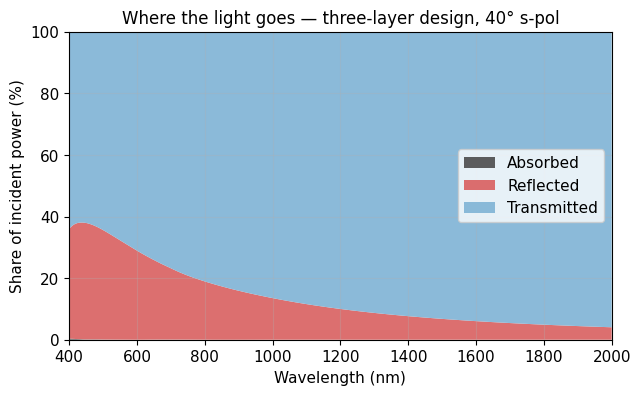

In [12]:
w, R = spectrum(three_layer, 40, 'reflectance',   lo=400, hi=2000, step=5, ref=600)
_, T = spectrum(three_layer, 40, 'transmittance', lo=400, hi=2000, step=5, ref=600)
_, A = spectrum(three_layer, 40, 'absorbance',    lo=400, hi=2000, step=5, ref=600)

total = R + T + A
print(f'R + T + A   min = {total.min():.10f} %   max = {total.max():.10f} %')
print(f'worst deviation from 100 %: {np.abs(total - 100).max():.2e} percentage points')

plt.stackplot(w, A, R, T, labels=['Absorbed', 'Reflected', 'Transmitted'],
              colors=['#4c4c4c', '#d95f5f', '#7fb3d5'], alpha=0.9)
plt.ylim(0, 100); plt.xlim(w.min(), w.max())
plt.xlabel('Wavelength (nm)'); plt.ylabel('Share of incident power (%)')
plt.title('Where the light goes — three-layer design, 40° s-pol')
plt.legend(loc='center right')
plt.show()


---
# 5. Angle and polarization

## 5.1 Brewster's angle

For a bare dielectric interface, p-polarized reflectance falls to zero at
$\theta_B=\arctan(n_2/n_1)$. This is a strong test of the angular machinery, because the
predicted angle is known in closed form.


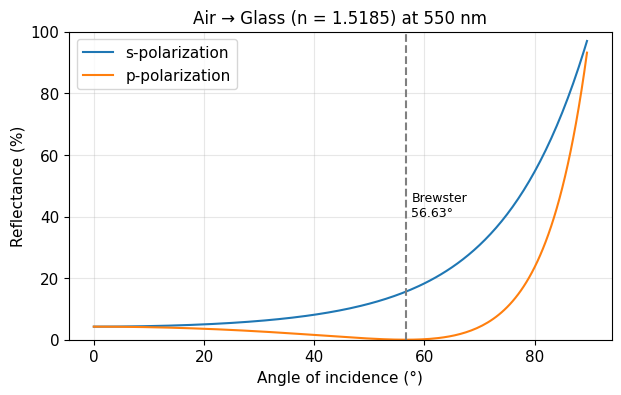

Predicted Brewster angle : 56.6337°
POCAL minimum of Rp      : 56.5000°   (Rp = 2.06e-04 %)


In [13]:
bare = write_stack('bare_glass.txt', [('Air', 0), ('Glass', 0)])

angles = np.arange(0, 90, 0.5)
Rs, Rp = [], []
for a in angles:
    _, r = spectrum(bare, a, 'reflectance', 's', lo=540, hi=560, step=10, ref=550)
    Rs.append(r[1])
    _, r = spectrum(bare, a, 'reflectance', 'p', lo=540, hi=560, step=10, ref=550)
    Rp.append(r[1])
Rs, Rp = np.array(Rs), np.array(Rp)

probe = pocal.pocal(bare, 0, 540, 560, 10, 550, False, None)
n_glass = probe.search_from_nr_k_generator(probe.nr_k_array, 'Glass')[0][1]
brewster = np.degrees(np.arctan(n_glass / 1.0))

plt.plot(angles, Rs, label='s-polarization')
plt.plot(angles, Rp, label='p-polarization')
plt.axvline(brewster, color='0.5', ls='--')
plt.text(brewster + 1, 40, f"Brewster\n{brewster:.2f}°", fontsize=9)
plt.xlabel('Angle of incidence (°)'); plt.ylabel('Reflectance (%)')
plt.title(f'Air → Glass (n = {n_glass:.4f}) at 550 nm')
plt.legend(); plt.ylim(0, 100)
plt.show()

print(f'Predicted Brewster angle : {brewster:.4f}°')
print(f'POCAL minimum of Rp      : {angles[Rp.argmin()]:.4f}°   (Rp = {Rp.min():.2e} %)')


## 5.2 Total internal reflection

Going the other way — glass into air — reflectance becomes total beyond the critical angle
$\theta_c=\arcsin(n_2/n_1)$. Because glass is dispersive, $\theta_c$ shifts slightly with
wavelength, and POCAL resolves that.


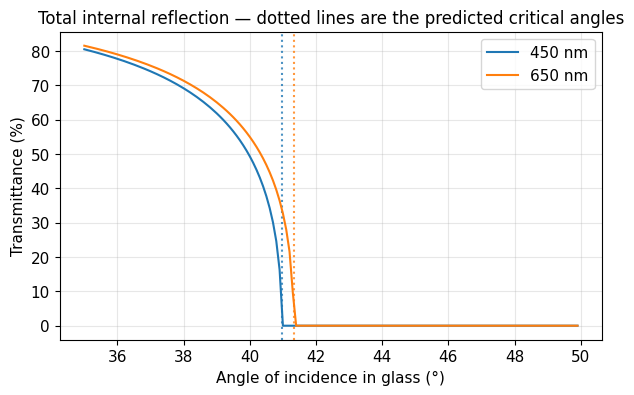

In [14]:
tir = write_stack('glass_to_air.txt', [('Glass', 0), ('Air', 0)])

angles = np.arange(35, 50, 0.1)
curves = {}
for wl in [450, 650]:
    vals = []
    for a in angles:
        _, t = spectrum(tir, a, 'transmittance', 's', lo=wl - 10, hi=wl + 10, step=10, ref=wl)
        vals.append(t[1])
    curves[wl] = np.array(vals)

probe = pocal.pocal(tir, 0, 440, 660, 10, 550, False, None)
n = probe.search_from_nr_k_generator(probe.nr_k_array, 'Glass')[0]
wg = probe.wave_spacing

for wl, v in curves.items():
    line, = plt.plot(angles, v, label=f'{wl} nm')
    tc = np.degrees(np.arcsin(1.0 / n[wg == wl][0]))
    plt.axvline(tc, color=line.get_color(), ls=':', alpha=0.8)

plt.xlabel('Angle of incidence in glass (°)'); plt.ylabel('Transmittance (%)')
plt.title('Total internal reflection — dotted lines are the predicted critical angles')
plt.legend()
plt.show()


## 5.3 Angle–wavelength map

Coatings blue-shift as the angle increases, because the effective optical thickness of every
layer shrinks like $\cos\theta$. A 2-D map shows the whole picture at once.


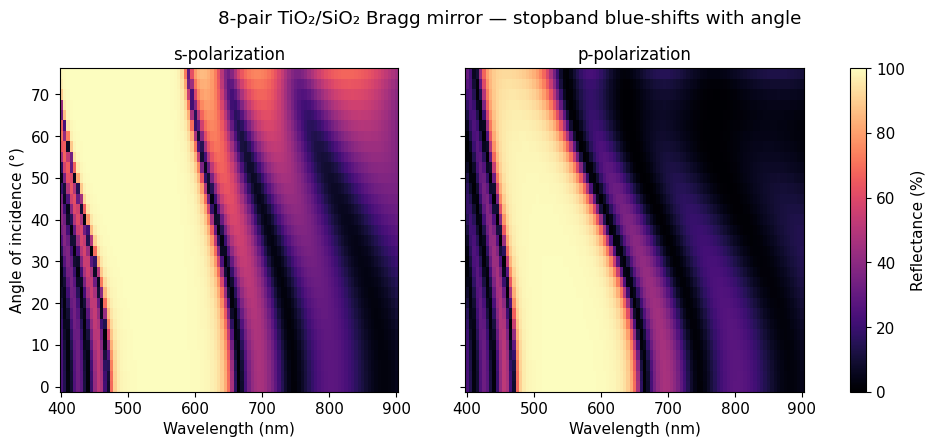

In [15]:
bragg8 = write_stack('bragg_8pair.txt',
                     [('Air', 0)] + [('TiO2', 0.25), ('SiO2', 0.25)] * 8 + [('Glass', 0)])

angle_grid = np.arange(0, 76, 2.5)
maps = {}
for pol in ['s', 'p']:
    rows = []
    for a in angle_grid:
        w, R = spectrum(bragg8, a, 'reflectance', pol, lo=400, hi=900, step=5,
                        ref=550, optical=True)
        rows.append(R)
    maps[pol] = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, pol in zip(axes, ['s', 'p']):
    im = ax.pcolormesh(w, angle_grid, maps[pol], cmap='magma', vmin=0, vmax=100,
                       shading='auto')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_title(f'{pol}-polarization')
    ax.grid(False)
axes[0].set_ylabel('Angle of incidence (°)')
fig.colorbar(im, ax=axes, label='Reflectance (%)')
fig.suptitle('8-pair TiO₂/SiO₂ Bragg mirror — stopband blue-shifts with angle', y=1.02)
plt.show()


---
# 6. Antireflection coatings

## 6.1 Optical thickness mode

Setting `opt_thick=True` lets you specify layers as a fraction of the reference wavelength.
A quarter-wave (`0.25`) of index $n_1=\sqrt{n_0 n_{sub}}$ gives **zero** reflectance at the
reference wavelength. For air onto glass that ideal is $n_1 \approx 1.23$; MgF₂ at 1.38 is the
closest practical material, which is why it coats almost every camera lens.


In [16]:
bare = write_stack('bare_glass.txt', [('Air', 0), ('Glass', 0)])
ar1 = write_stack('ar_mgf2.txt', [('Air', 0), ('MgF2', 0.25), ('Glass', 0)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1.4]})
draw_stack(ar1, ref_wave=550, optical=True, ax=ax1, title='MgF₂ single-layer AR')

w, R0 = spectrum(bare, 0, 'reflectance')
w, R1 = spectrum(ar1, 0, 'reflectance', optical=True, ref=550)

ax2.plot(w, R0, label='Uncoated glass', color='0.4')
ax2.plot(w, R1, label='+ quarter-wave MgF₂', color='seagreen')
ax2.axvline(550, color='0.7', ls=':')
ax2.set(xlabel='Wavelength (nm)', ylabel='Reflectance (%)', title='Single-layer AR at 550 nm')
ax2.legend()
plt.tight_layout()
plt.show()

i = np.argmin(abs(w - 550))
print(f'At 550 nm:  uncoated {R0[i]:.3f} %   coated {R1[i]:.3f} %'
      f'   ({100 * (1 - R1[i] / R0[i]):.0f} % reduction)')


<Figure size 700x400 with 0 Axes>

At 550 nm:  uncoated 4.239 %   coated 1.343 %   (68 % reduction)


## 6.2 Why one layer isn't enough — the V-coat

A single layer only nulls at one wavelength. The classic quarter–quarter **V-coat** uses two
materials to deepen the null; a quarter–half–quarter stack broadens it instead. Compare the
shapes:


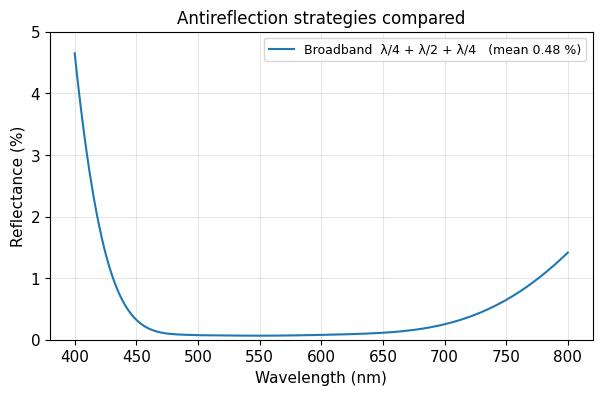

In [17]:
designs = {
    'Uncoated':                 (bare, False),
    'MgF₂  λ/4':                (ar1, True),
    'V-coat  Al₂O₃ λ/4 + MgF₂ λ/4':
        (write_stack('ar_v.txt', [('Air', 0), ('MgF2', 0.25), ('Al2O3', 0.25), ('Glass', 0)]), True),
    'Broadband  λ/4 + λ/2 + λ/4':
        (write_stack('ar_broad.txt', [('Air', 0), ('MgF2', 0.25), ('ZrO2', 0.5),
                                      ('Al2O3', 0.25), ('Glass', 0)]), True),
}

for label, (path, optical) in designs.items():
    w, R = spectrum(path, 0, 'reflectance', lo=400, hi=800, step=2, ref=550, optical=optical)
    plt.plot(w, R, label=f'{label}   (mean {R.mean():.2f} %)')

plt.xlabel('Wavelength (nm)'); plt.ylabel('Reflectance (%)')
plt.title('Antireflection strategies compared')
plt.legend(fontsize=9); plt.ylim(0, 5)
plt.show()


---
# 7. Bragg mirrors

Alternating quarter-waves of high and low index build reflectance up geometrically. With $N$
pairs of indices $n_H, n_L$ on a substrate $n_s$, the peak reflectance approaches

$$Y=\left(\frac{n_H}{n_L}\right)^{2N}n_s,\qquad
R=\left(\frac{n_0-Y}{n_0+Y}\right)^{2}$$

## 7.1 Stopband growth


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

peak = {}
for pairs in [1, 2, 4, 6, 8, 12]:
    path = write_stack(f'bragg_{pairs}.txt',
                       [('Air', 0)] + [('TiO2', 0.25), ('SiO2', 0.25)] * pairs + [('Glass', 0)])
    w, R = spectrum(path, 0, 'reflectance', lo=350, hi=900, step=2, ref=550, optical=True)
    ax1.plot(w, R, label=f'{pairs} pair' + ('s' if pairs > 1 else ''))
    peak[pairs] = R[np.argmin(abs(w - 550))]

ax1.set(xlabel='Wavelength (nm)', ylabel='Reflectance (%)',
        title='TiO₂/SiO₂ quarter-wave stack, centred at 550 nm')
ax1.legend(fontsize=9)

ax2.semilogy(list(peak), [100 - v for v in peak.values()], 'o-', color='crimson')
ax2.set(xlabel='Number of pairs', ylabel='100 − R  (%)',
        title='Residual transmission falls geometrically')
plt.tight_layout()
plt.show()

for pairs, value in peak.items():
    print(f'{pairs:>3} pairs   R(550 nm) = {value:9.5f} %')


<Figure size 700x400 with 0 Axes>

  1 pairs   R(550 nm) =  34.30130 %
  2 pairs   R(550 nm) =  65.94623 %
  4 pairs   R(550 nm) =  93.65445 %
  6 pairs   R(550 nm) =  98.94791 %
  8 pairs   R(550 nm) =  99.80784 %
 12 pairs   R(550 nm) =  99.96529 %


## 7.2 Narrowband filter — the Fabry–Pérot cavity

Put a half-wave **spacer** between two Bragg mirrors and the stopband develops a razor-thin
transmission peak. This is how laser-line and fluorescence filters are made.


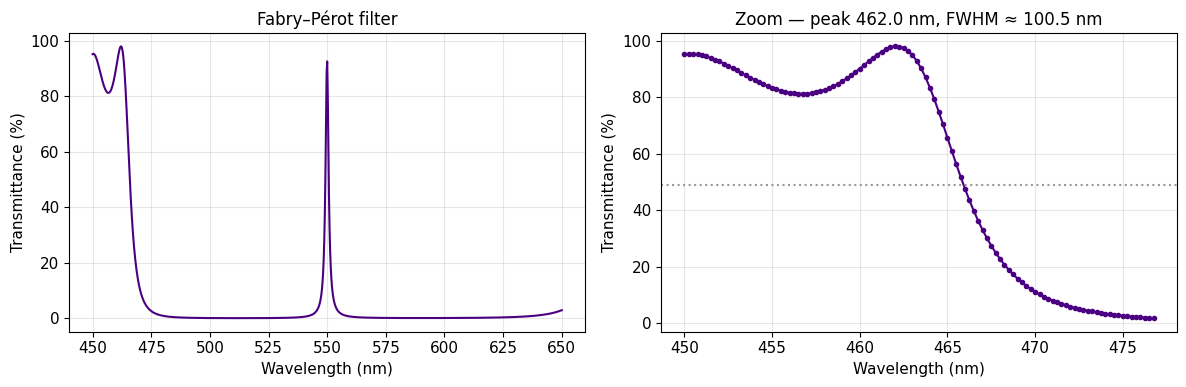

In [19]:
cavity = write_stack('fabry_perot.txt',
                     [('Air', 0)]
                     + [('TiO2', 0.25), ('SiO2', 0.25)] * 5
                     + [('SiO2', 0.5)]                       # half-wave spacer
                     + [('SiO2', 0.25), ('TiO2', 0.25)] * 5
                     + [('Glass', 0)])

w, T = spectrum(cavity, 0, 'transmittance', lo=450, hi=650, step=0.25, ref=550, optical=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(w, T, color='indigo')
ax1.set(xlabel='Wavelength (nm)', ylabel='Transmittance (%)', title='Fabry–Pérot filter')

peak_i = T.argmax()
half = T.max() / 2
above = np.where(T > half)[0]
fwhm = w[above[-1]] - w[above[0]] if len(above) > 1 else float('nan')

m = abs(w - w[peak_i]) < 15
ax2.plot(w[m], T[m], color='indigo', marker='.')
ax2.axhline(half, color='0.6', ls=':')
ax2.set(xlabel='Wavelength (nm)', ylabel='Transmittance (%)',
        title=f'Zoom — peak {w[peak_i]:.1f} nm, FWHM ≈ {fwhm:.1f} nm')
plt.tight_layout()
plt.show()


---
# 8. Metallic and absorbing films

Metals have large $k$, so they absorb. POCAL handles complex indices throughout — the
absorbance channel is where that shows up.

## 8.1 How thick does a silver mirror need to be?


In [20]:
thicknesses = [5, 10, 20, 40, 80, 150]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
rows = []
for d in thicknesses:
    path = write_stack(f'ag_{d}.txt', [('Air', 0), ('Ag', d), ('Glass', 0)])
    w, R = spectrum(path, 0, 'reflectance', lo=400, hi=800, step=5)
    _, T = spectrum(path, 0, 'transmittance', lo=400, hi=800, step=5)
    _, A = spectrum(path, 0, 'absorbance', lo=400, hi=800, step=5)
    ax1.plot(w, R, label=f'{d} nm')
    i = np.argmin(abs(w - 550))
    rows.append((d, R[i], T[i], A[i]))

ax1.set(xlabel='Wavelength (nm)', ylabel='Reflectance (%)', title='Silver film on glass')
ax1.legend(fontsize=9, title='thickness')

d, r, t, a = zip(*rows)
ax2.plot(d, r, 'o-', label='Reflected')
ax2.plot(d, t, 's-', label='Transmitted')
ax2.plot(d, a, '^-', label='Absorbed')
ax2.set(xlabel='Silver thickness (nm)', ylabel='Share at 550 nm (%)', title='Power budget')
ax2.legend()
plt.tight_layout()
plt.show()

print(f"{'d (nm)':>7} {'R %':>9} {'T %':>9} {'A %':>9} {'sum':>10}")
for d_, r_, t_, a_ in rows:
    print(f'{d_:>7} {r_:>9.3f} {t_:>9.3f} {a_:>9.3f} {r_ + t_ + a_:>10.6f}')


<Figure size 700x400 with 0 Axes>

 d (nm)       R %       T %       A %        sum
      5    11.750    87.037     1.213 100.000000
     10    28.635    69.346     2.019 100.000000
     20    61.720    35.799     2.481 100.000000
     40    89.942     7.908     2.149 100.000000
     80    97.777     0.379     1.844 100.000000
    150    98.185     0.002     1.813 100.000000


## 8.2 A beam splitter

A thin metal film that deliberately splits the beam. Unlike a dielectric splitter, some power
is always lost to absorption — the trade-off is that it works over a very wide band.


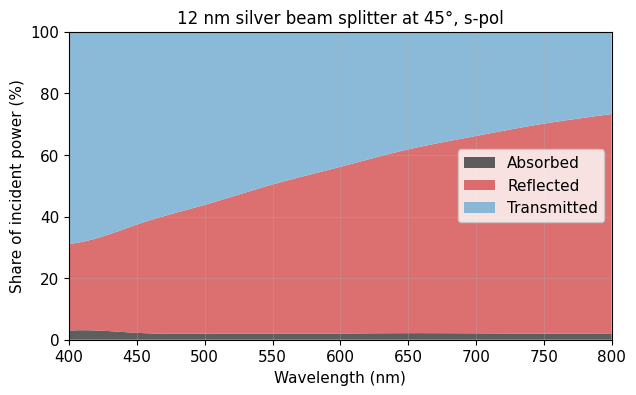

In [21]:
splitter = write_stack('splitter.txt', [('Air', 0), ('Ag', 12), ('Glass', 0)])

w, R = spectrum(splitter, 45, 'reflectance', 's', lo=400, hi=800, step=5)
_, T = spectrum(splitter, 45, 'transmittance', 's', lo=400, hi=800, step=5)
_, A = spectrum(splitter, 45, 'absorbance', 's', lo=400, hi=800, step=5)

plt.stackplot(w, A, R, T, labels=['Absorbed', 'Reflected', 'Transmitted'],
              colors=['#4c4c4c', '#d95f5f', '#7fb3d5'], alpha=0.9)
plt.xlim(w.min(), w.max()); plt.ylim(0, 100)
plt.xlabel('Wavelength (nm)'); plt.ylabel('Share of incident power (%)')
plt.title('12 nm silver beam splitter at 45°, s-pol')
plt.legend(loc='center right')
plt.show()


---
# 9. Phase shift, group delay and GDD

Beyond intensity, POCAL returns the phase the coating imposes:

$$\varphi_R=\arctan\left(\frac{\mathrm{Im}(\eta_{sub}(BC^*-CB^*))}
{\eta_{sub}^2BB^*-CC^*}\right),\qquad
\varphi_T=\arctan\left(\frac{-\mathrm{Im}(\eta_0B+C)}{\mathrm{Re}(\eta_0B+C)}\right)$$

Differentiating with respect to angular frequency gives group delay and group delay dispersion,
which matter for ultrafast pulses:

$$GD=-\frac{d\varphi}{d\omega}=\frac{\lambda^2}{2\pi c}\frac{d\varphi}{d\lambda},
\qquad GDD=-\frac{d^2\varphi}{d\omega^2}
=\left(\frac{\lambda^2}{2\pi c}\right)^{\!2}\frac{d^2\varphi}{d\lambda^2}$$

## 9.1 Phase of the three-layer design


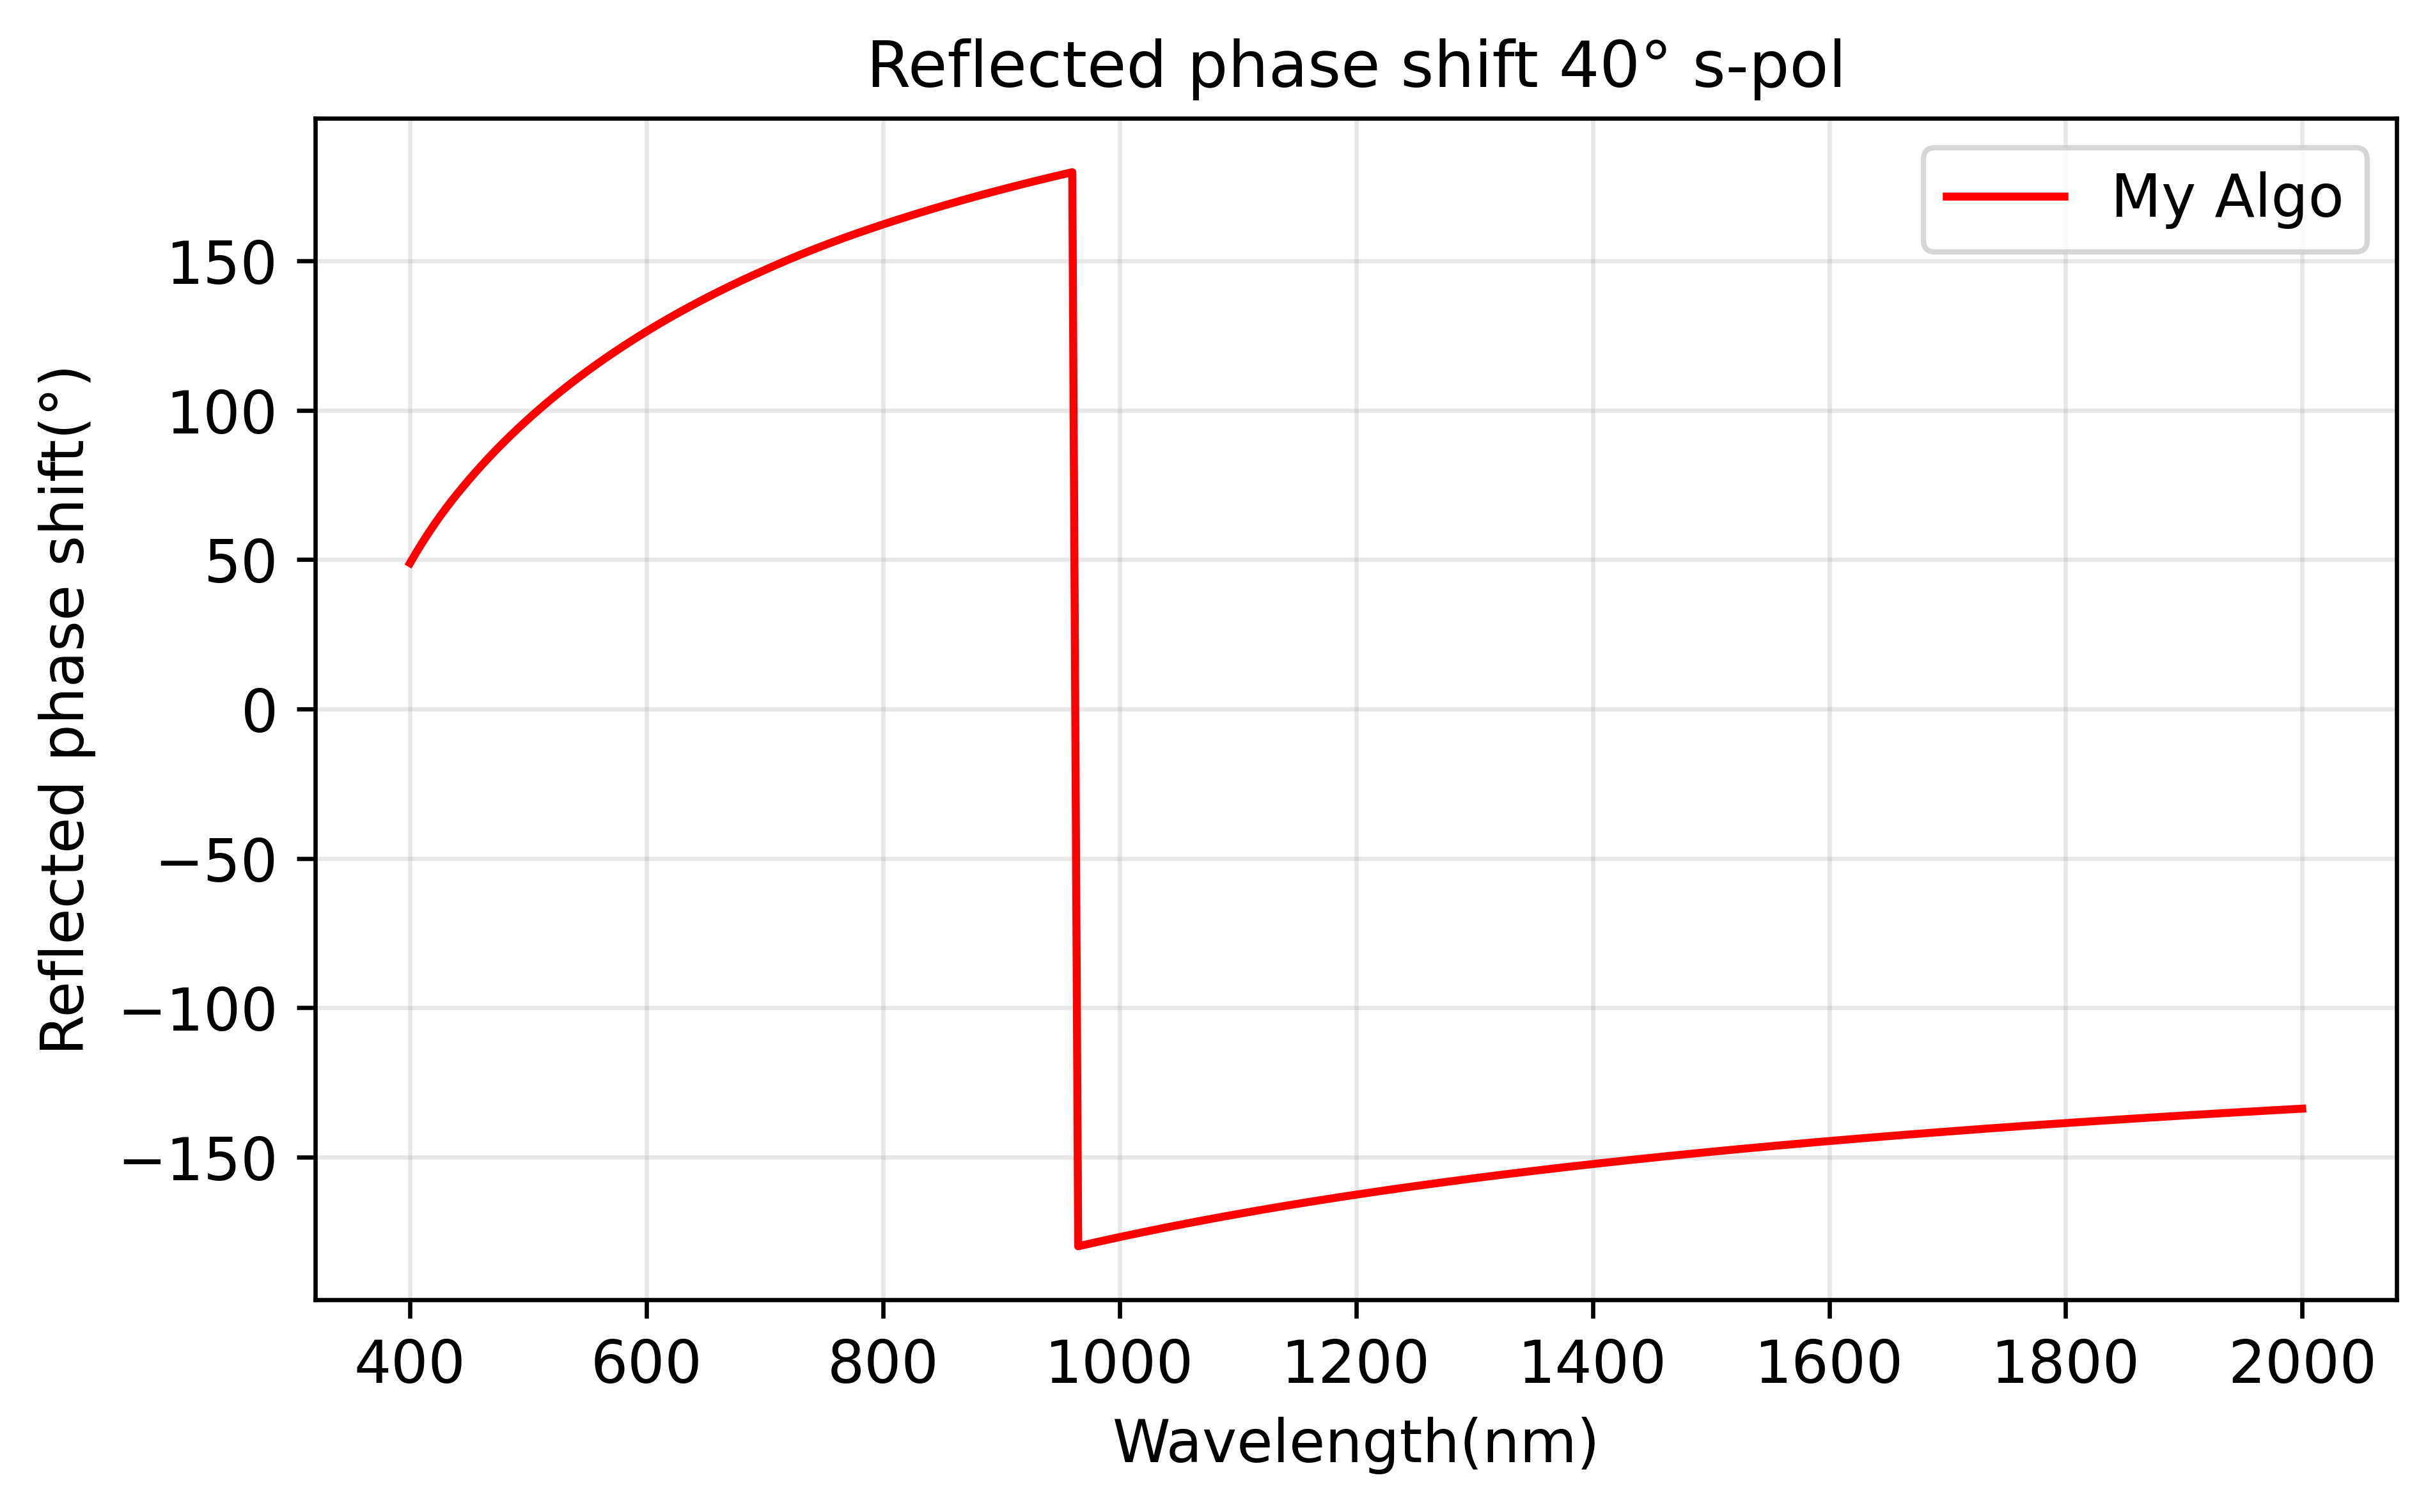

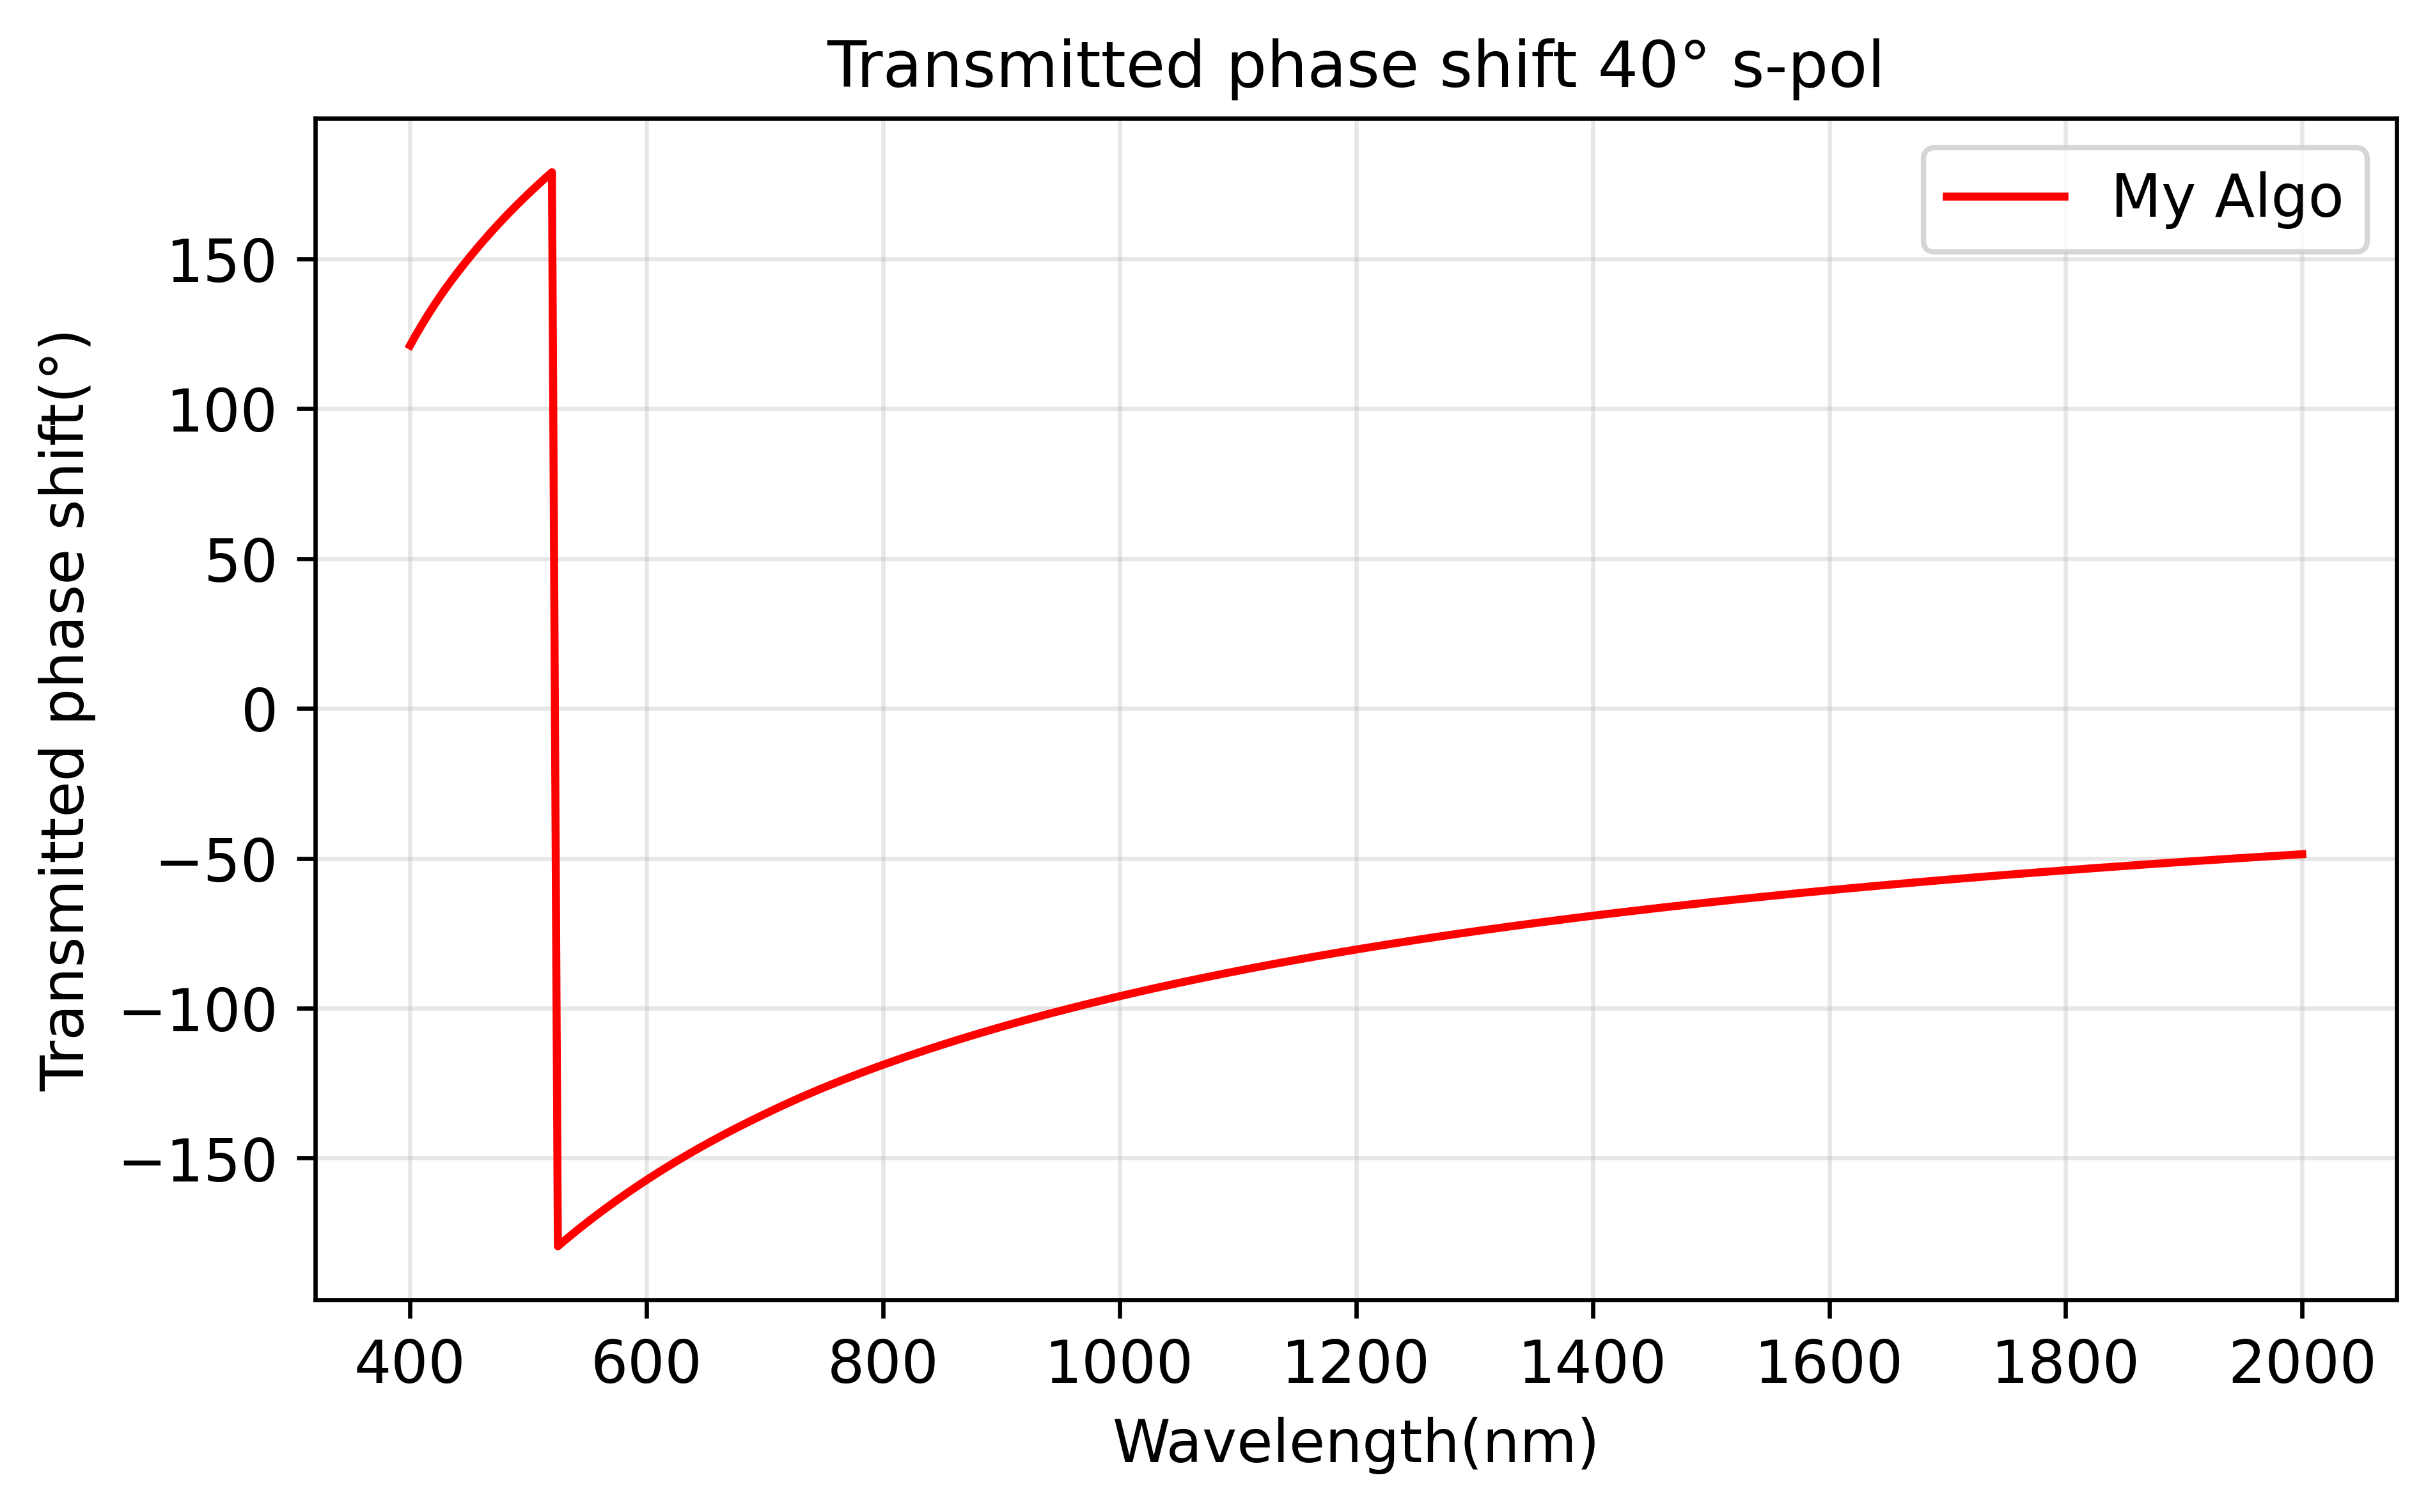

In [22]:
stack = pocal.pocal(three_layer, 40, 400, 2000, 5, 600, False, None)
stack.s_polarization('reflected_phase_shift', False, False)
stack.s_polarization('transmitted_phase_shift', False, False)
plt.show()


The jumps are wraps of the arctangent into $(-180°, 180°]$, not physical discontinuities.
Because GD and GDD are numerical derivatives of this curve, the wraps produce **spikes** —
the paper discusses this in Section 3.3. Interpret GD/GDD away from the jumps.


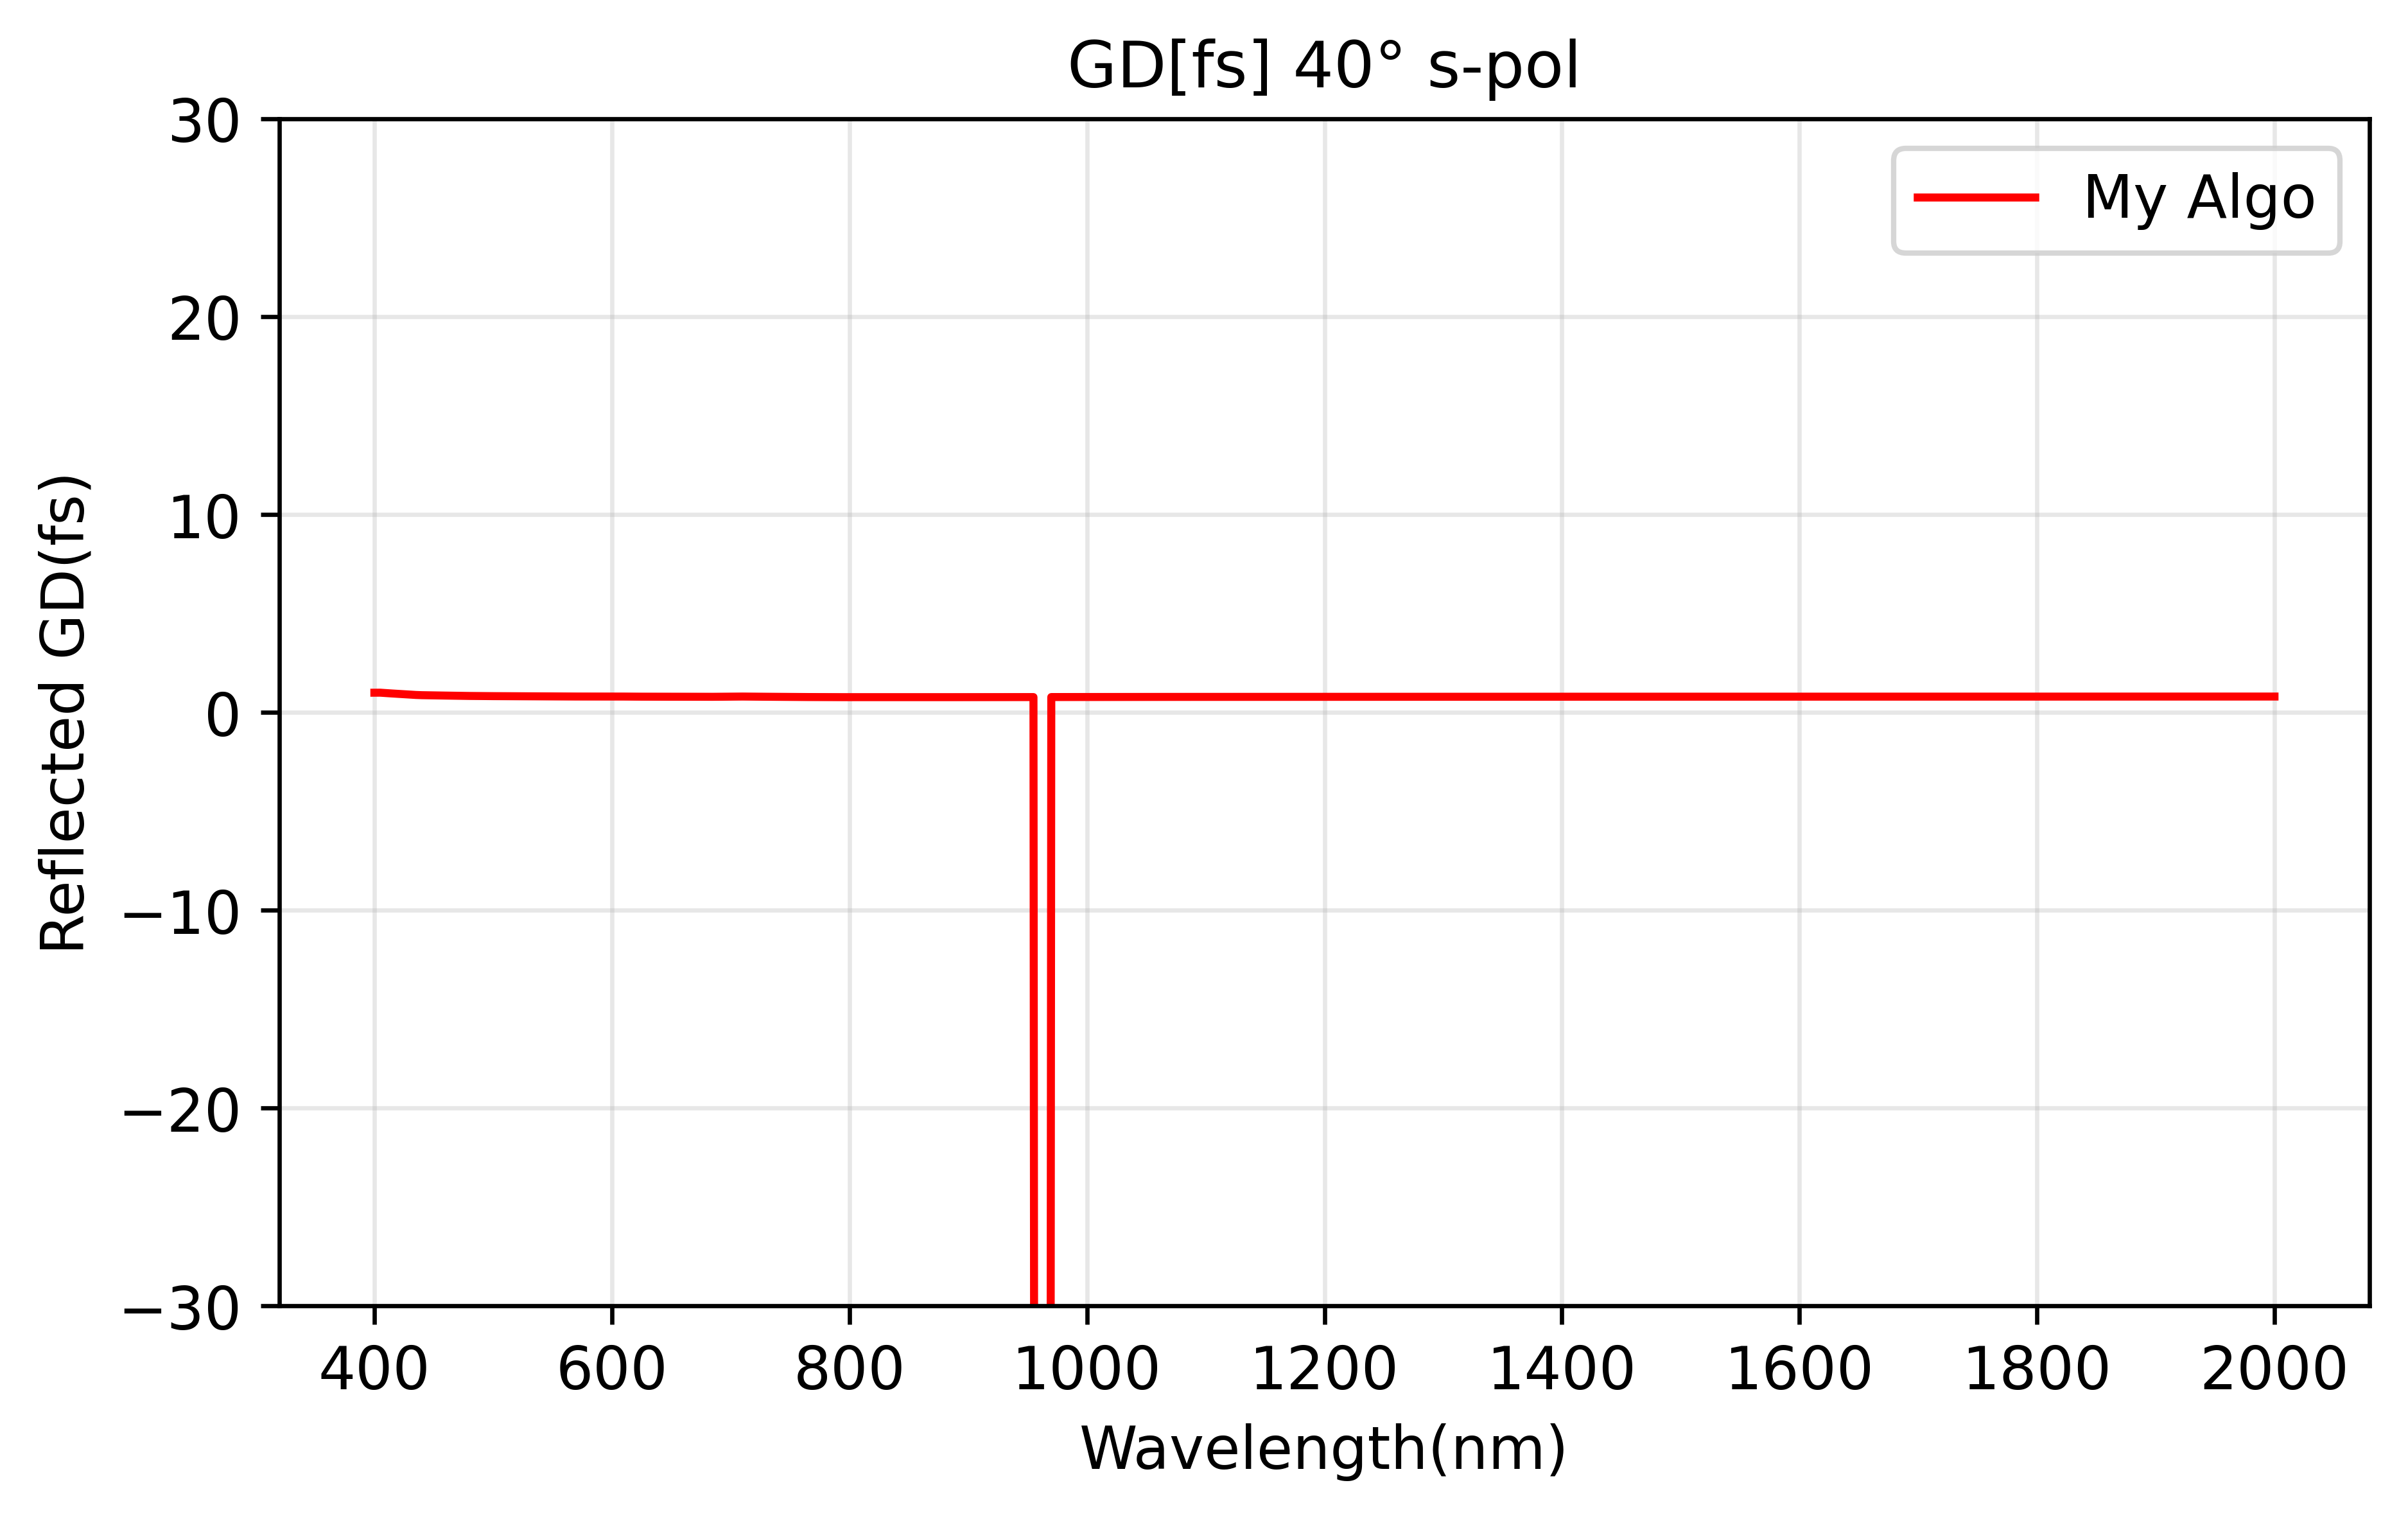

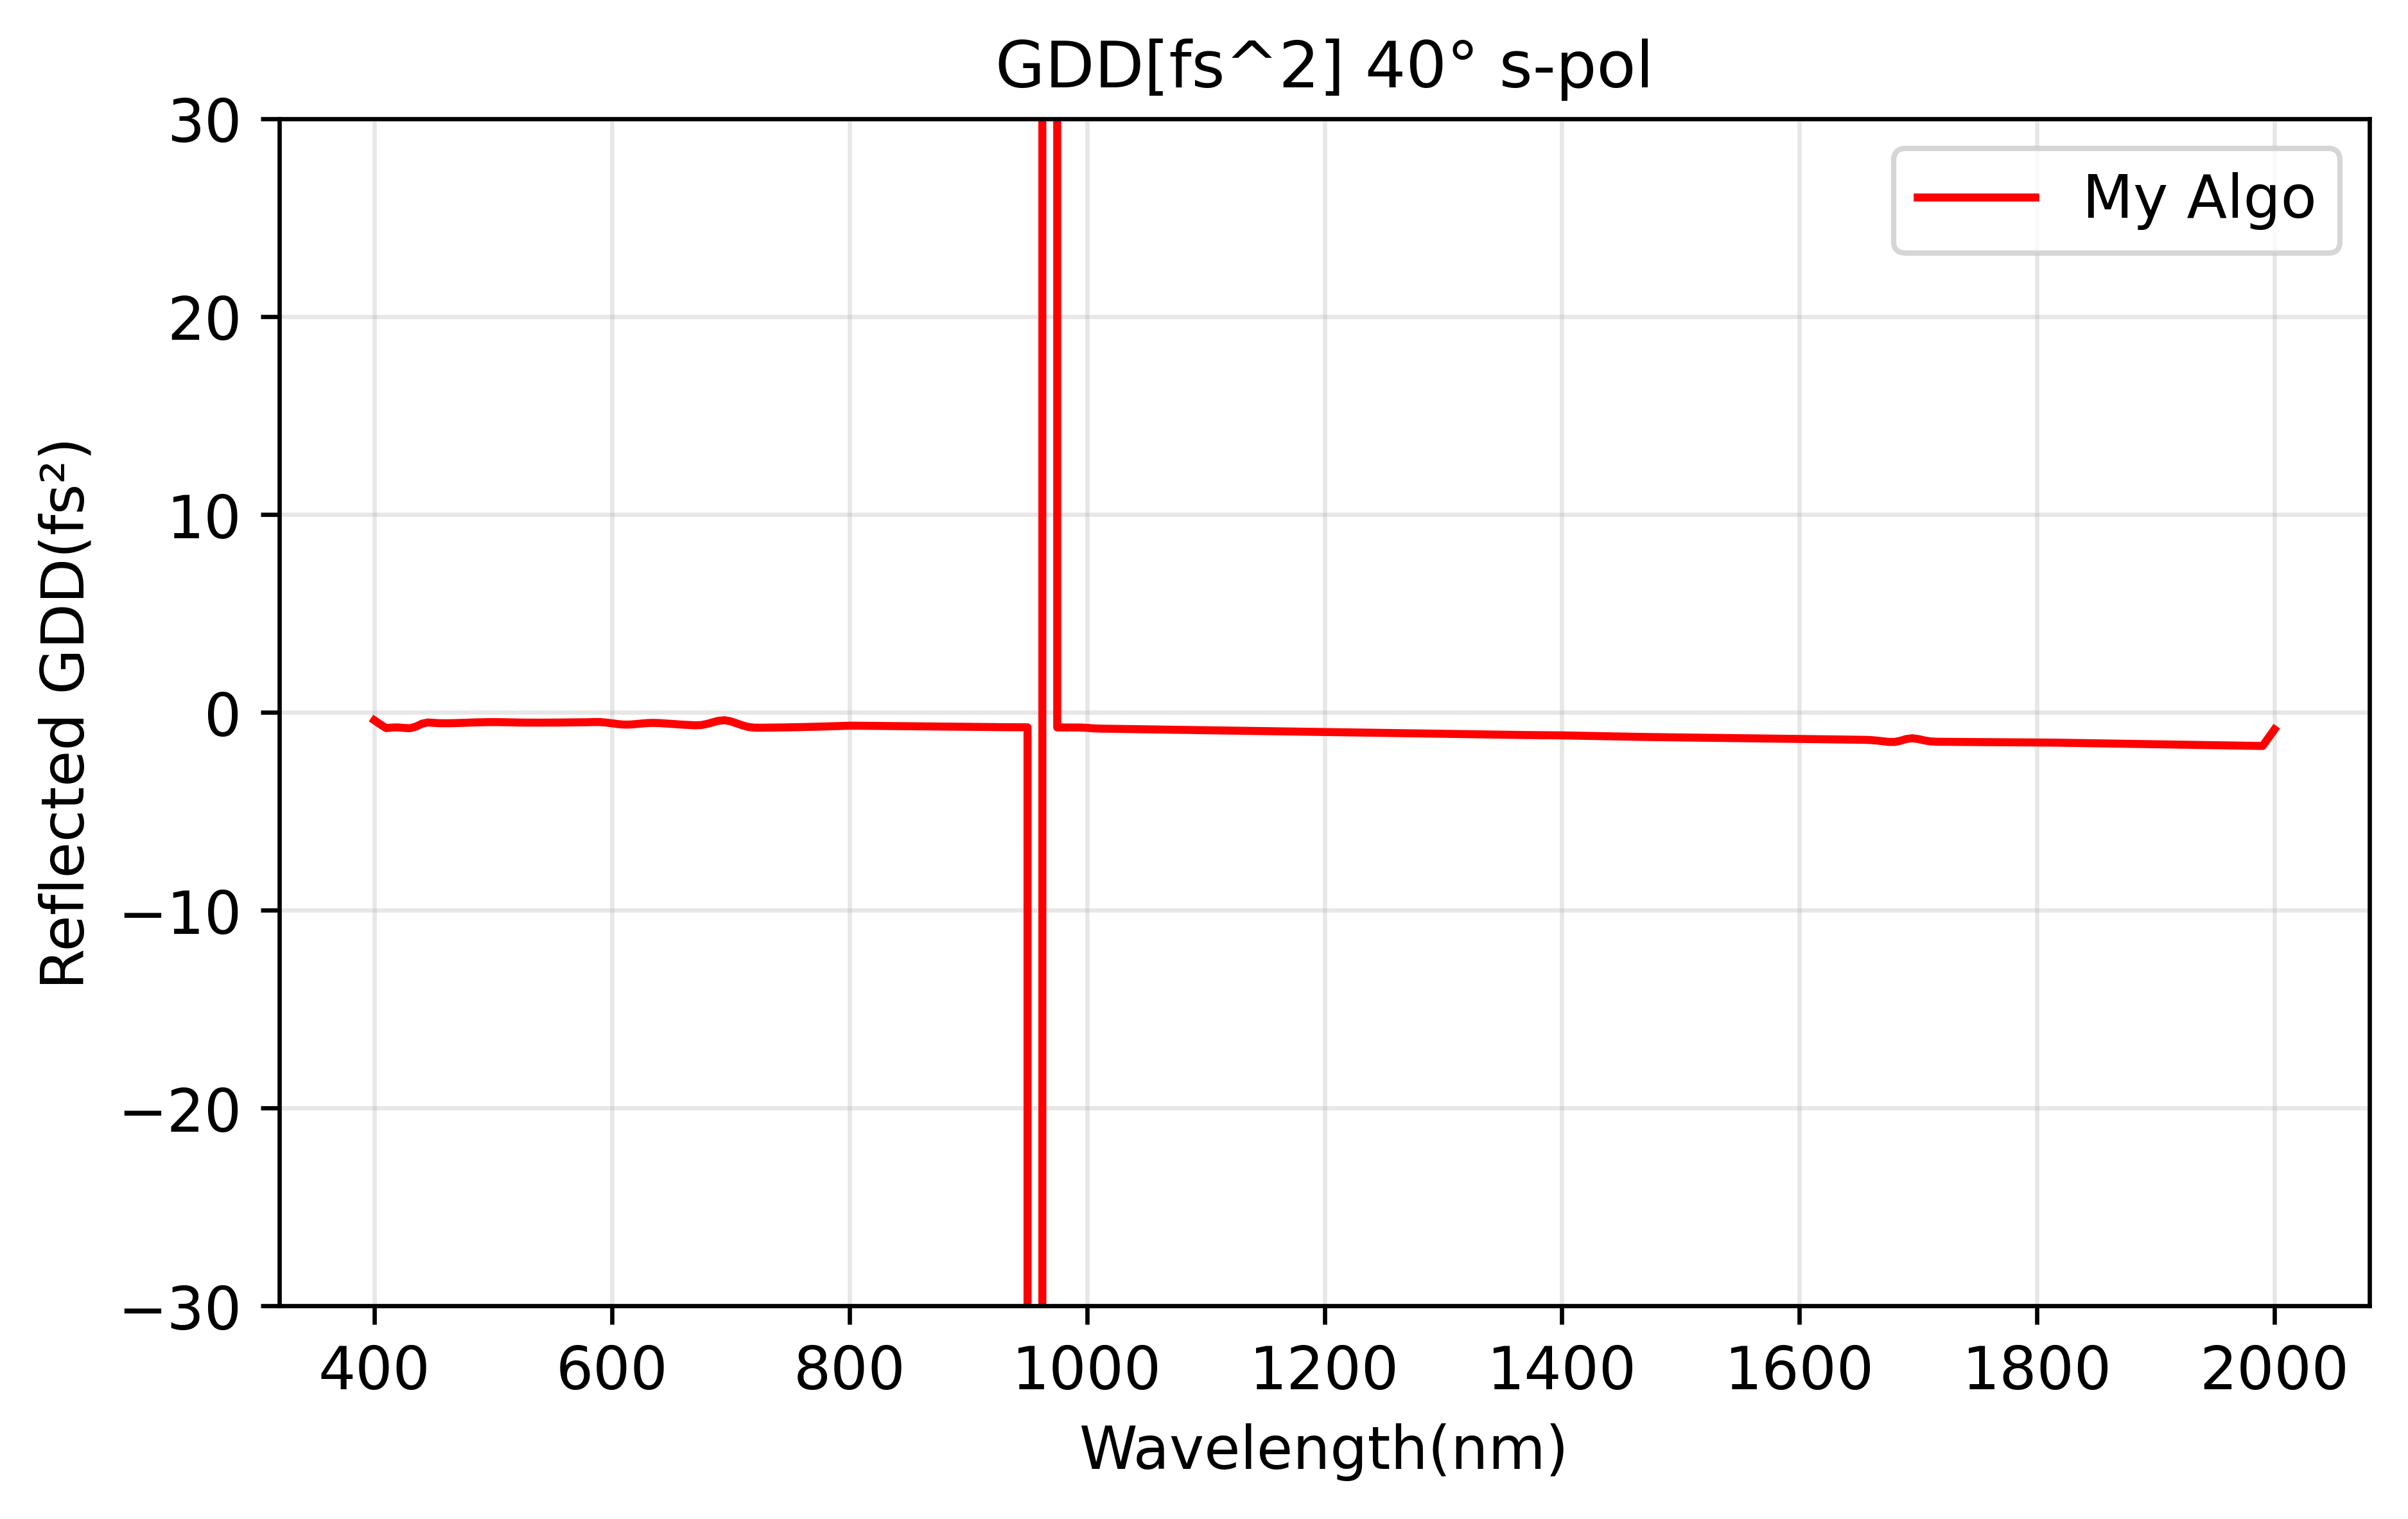

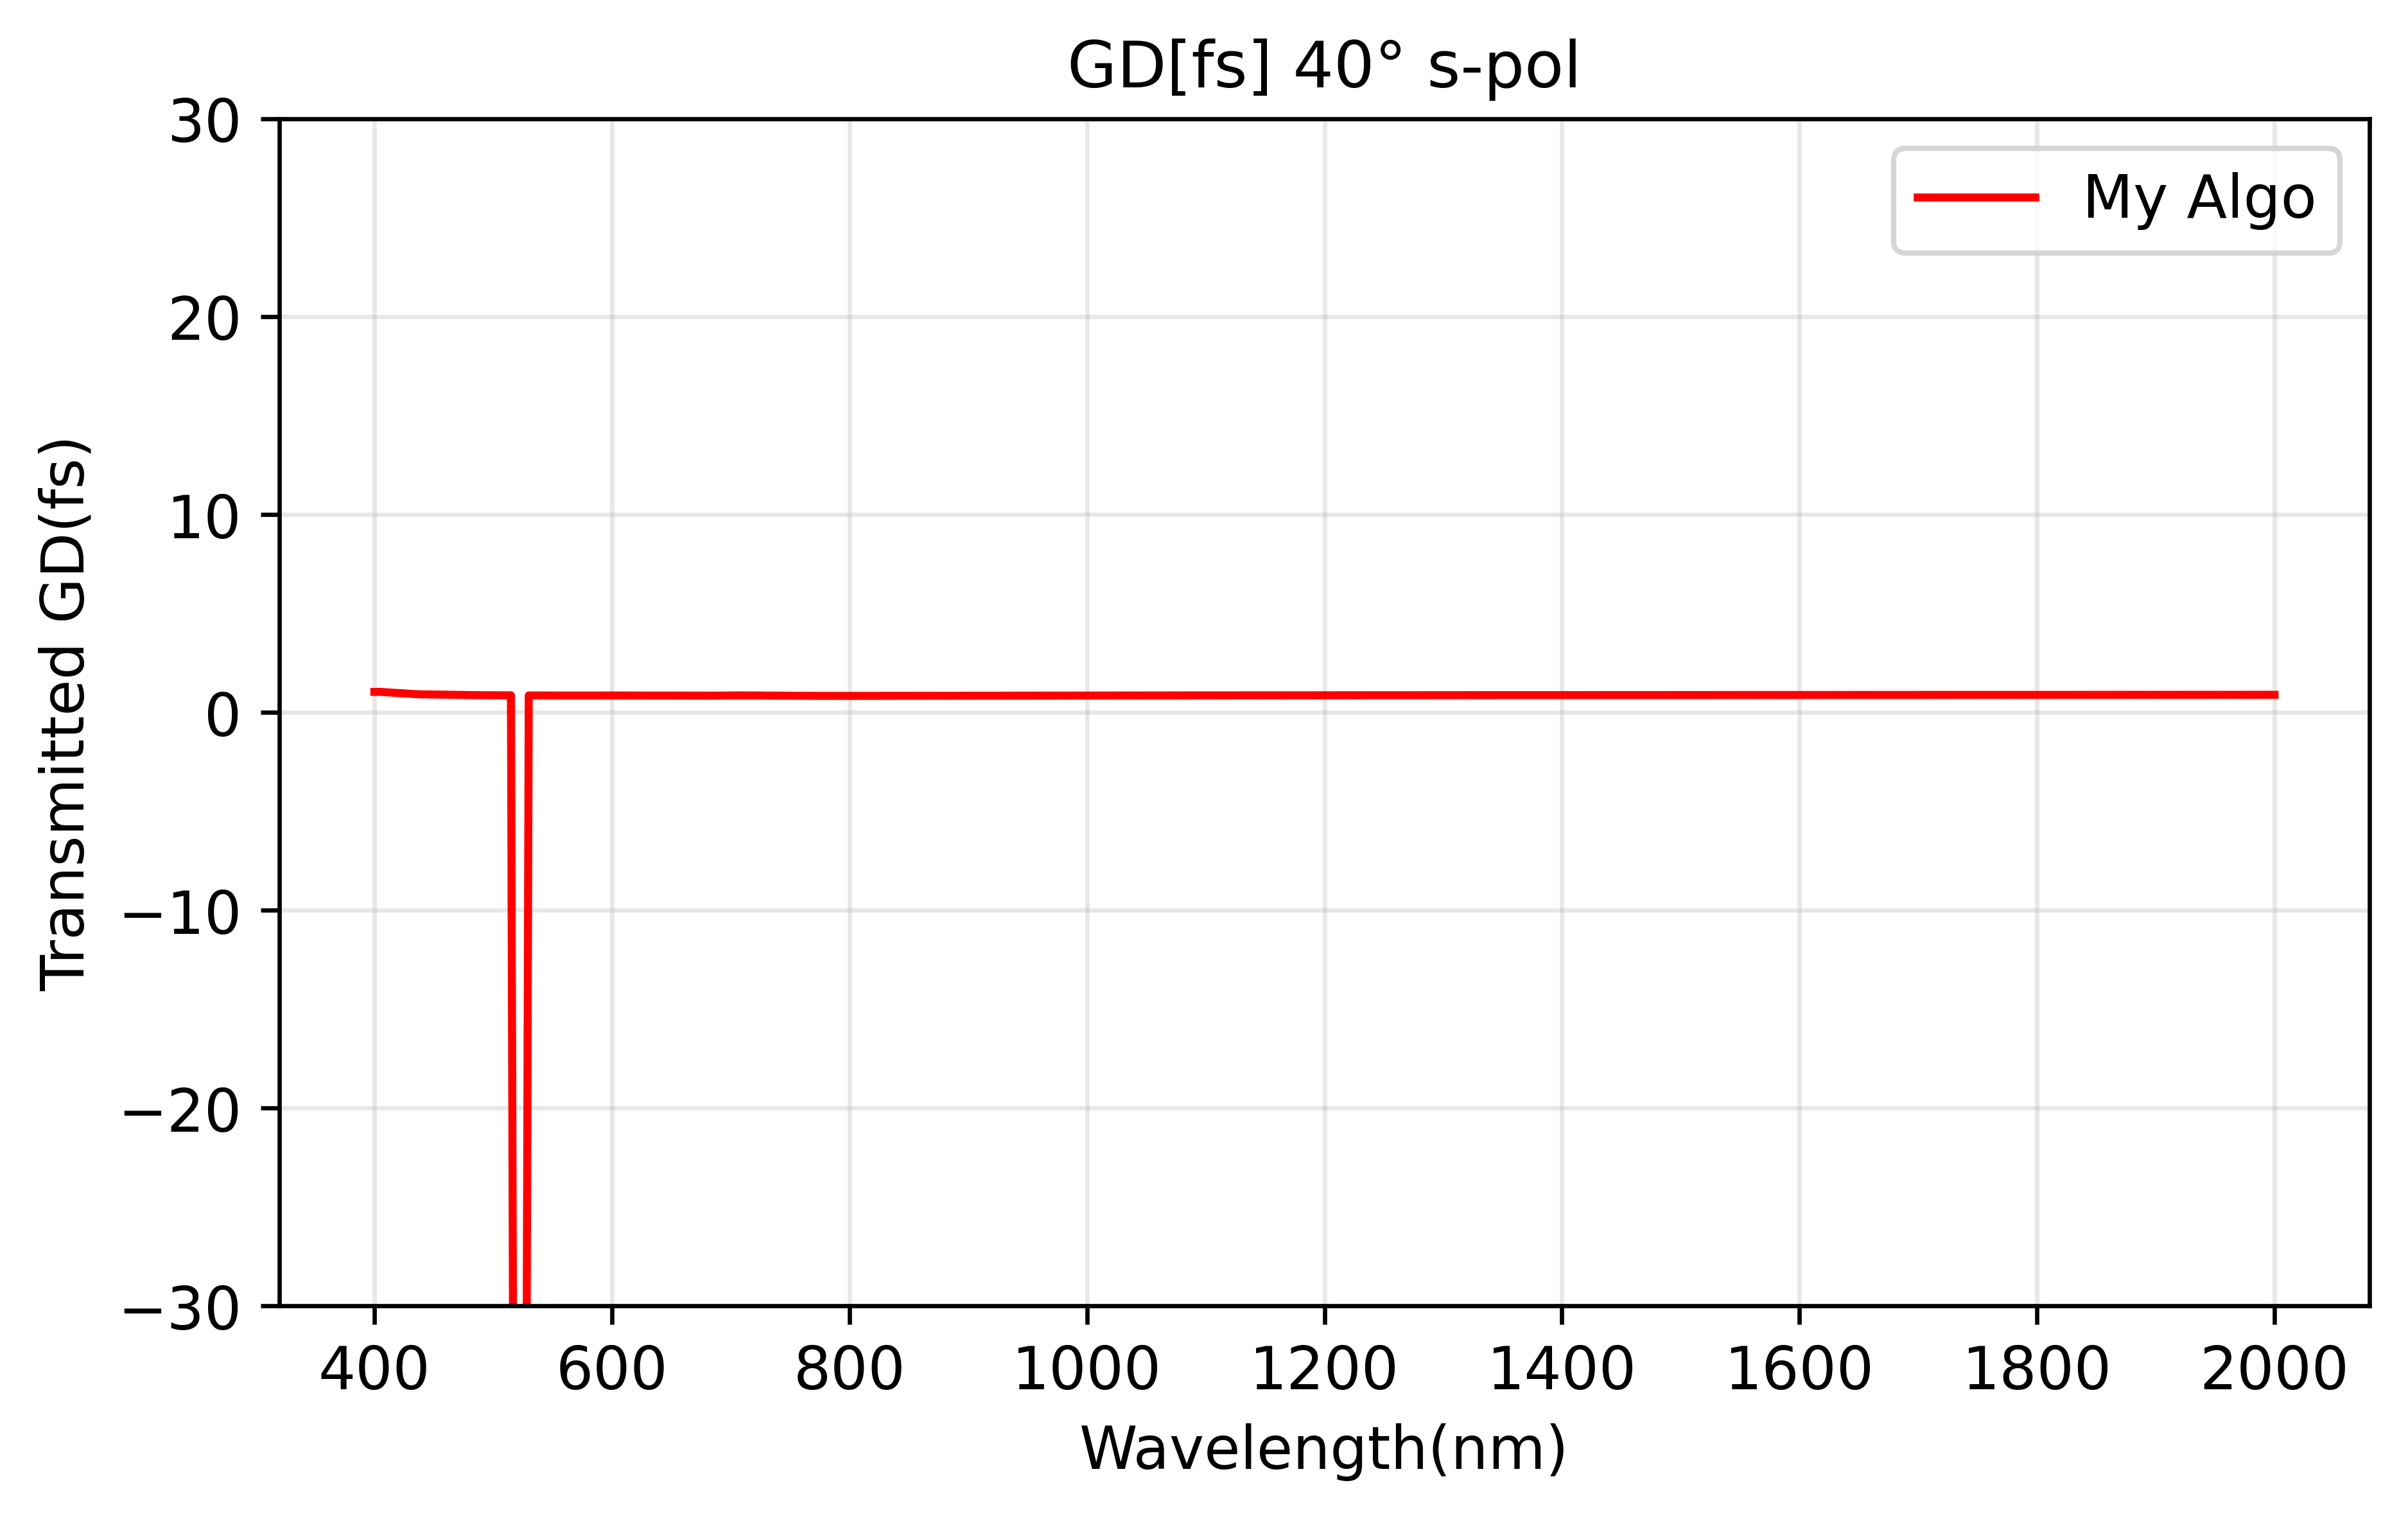

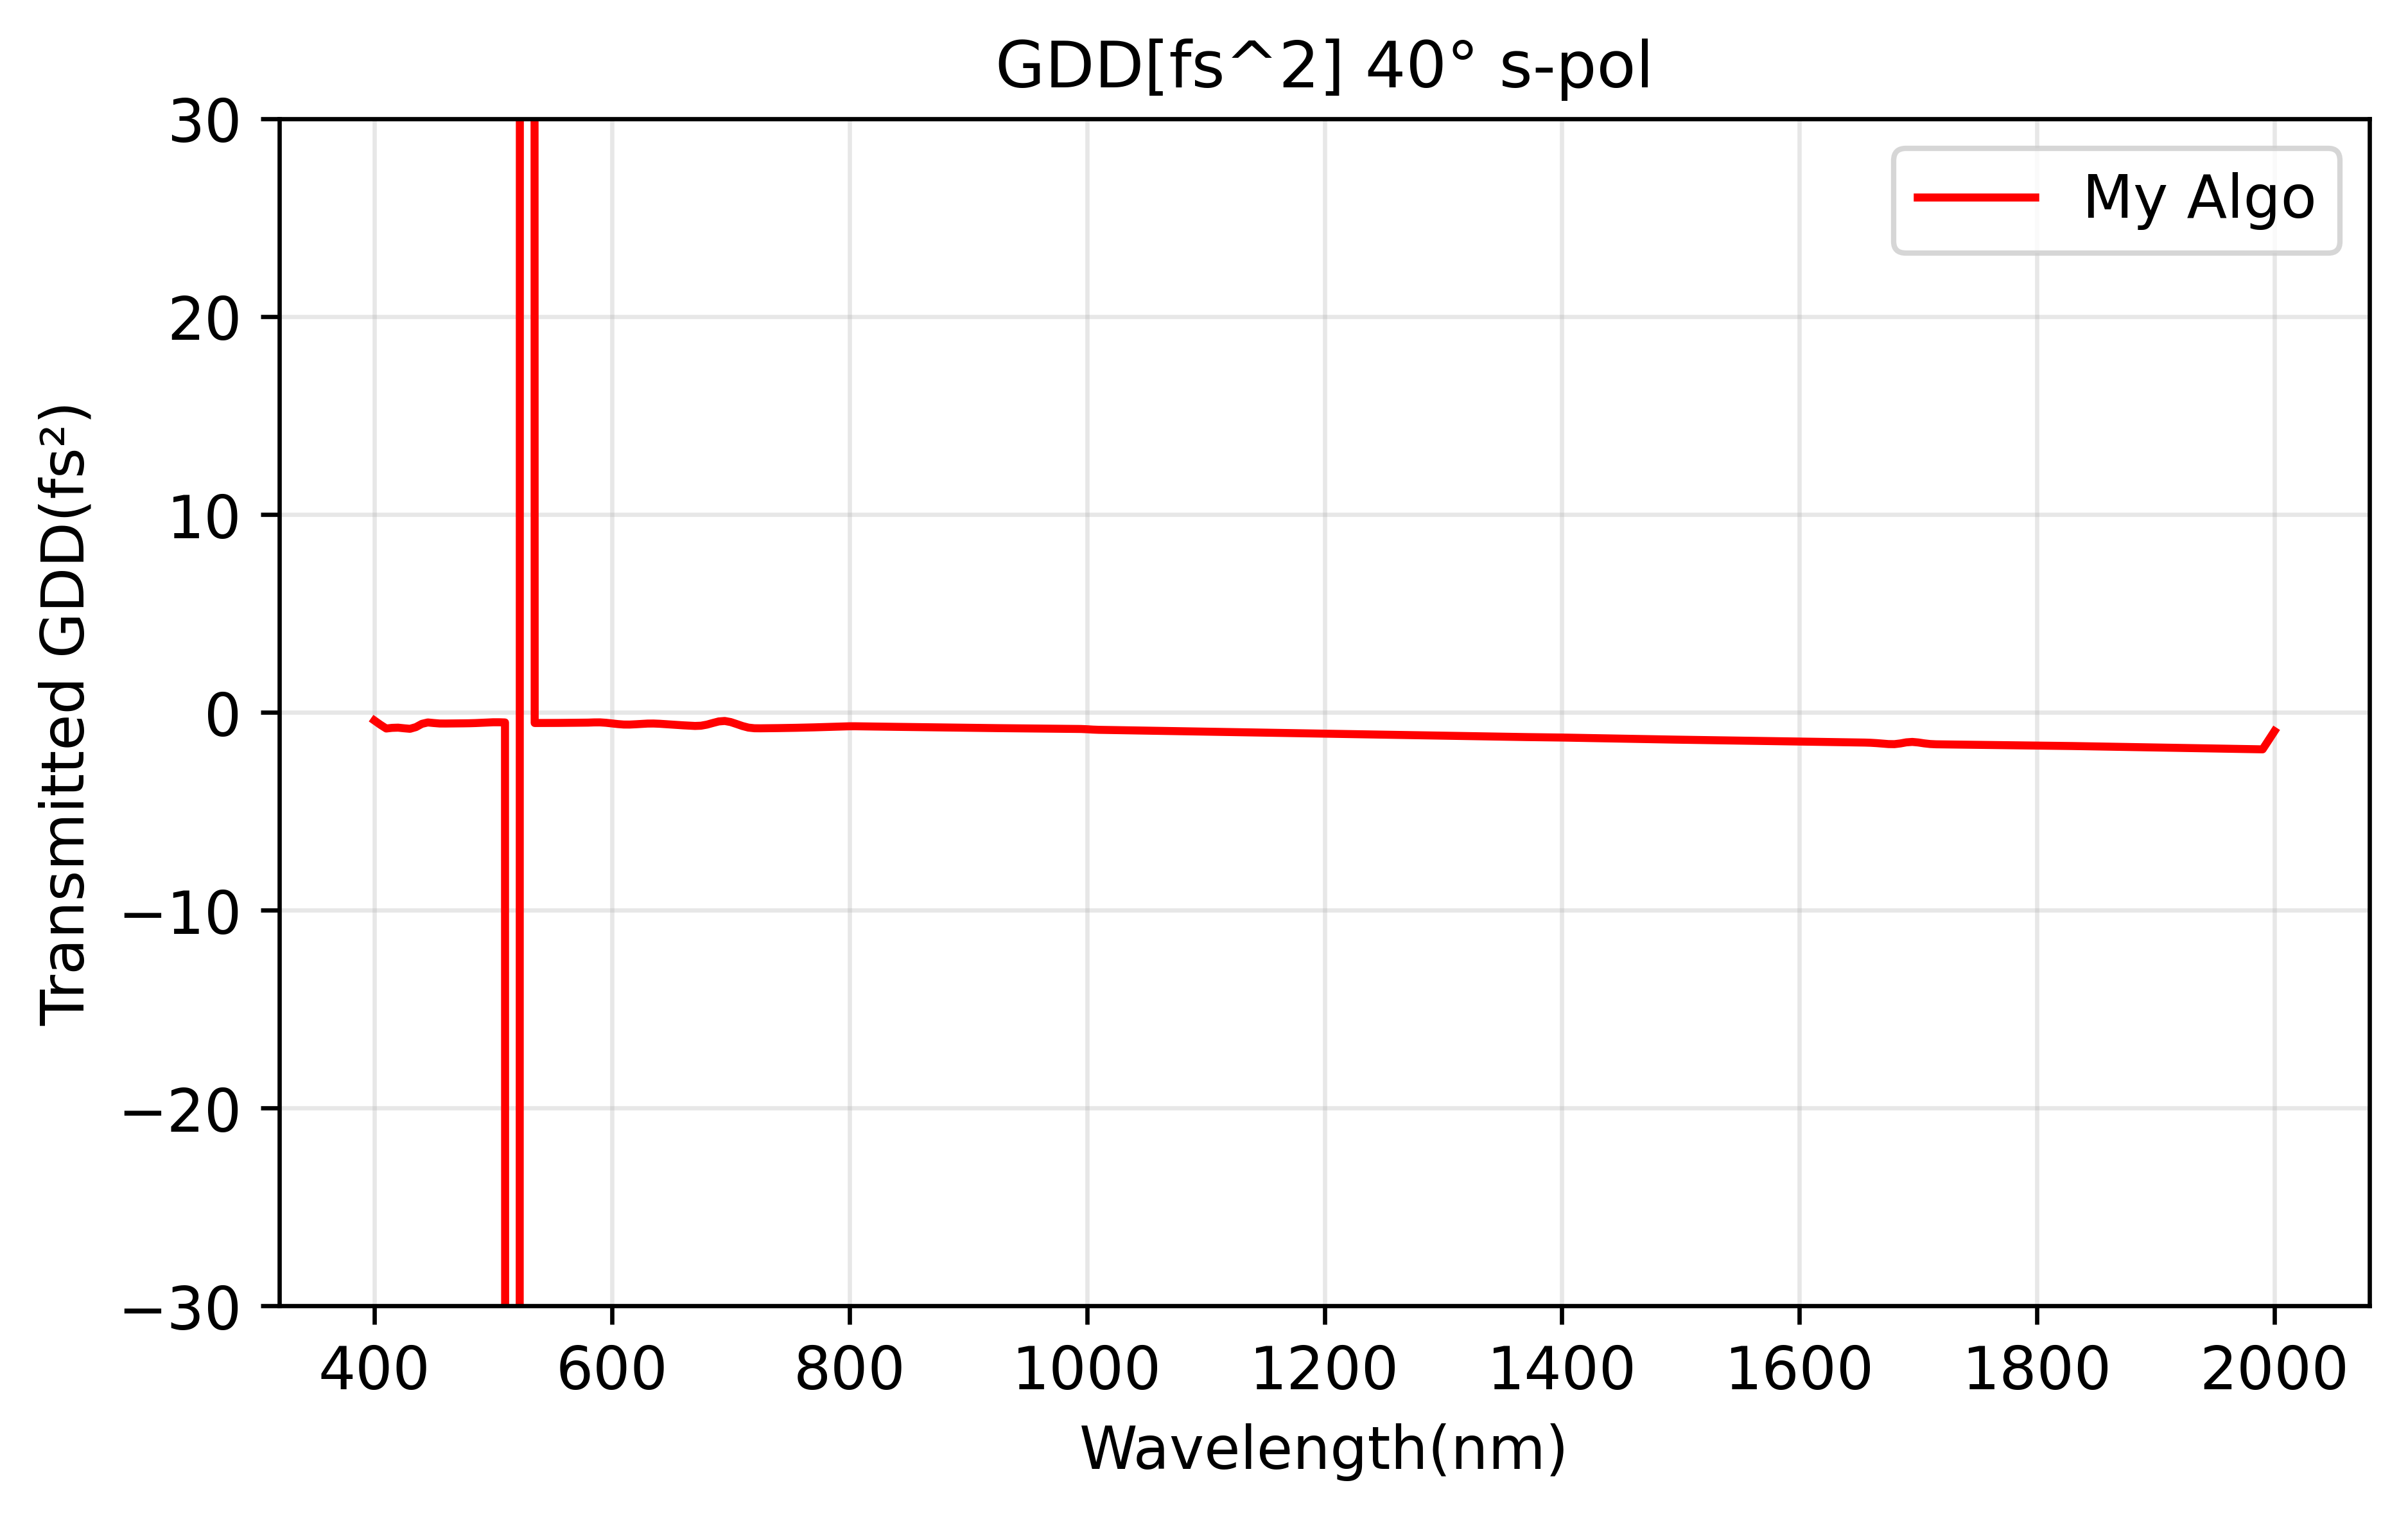

In [23]:
stack = pocal.pocal(three_layer, 40, 400, 2000, 5, 600, False, None)
stack.s_polarization('GD_ref', False, False)
stack.s_polarization('GDD_ref', False, False)
stack.s_polarization('GD_trans', False, False)
stack.s_polarization('GDD_trans', False, False)
plt.show()


## 9.2 A chirped mirror

Gradually increasing the layer periods sends different wavelengths to different depths, so each
colour picks up a different delay. This is the basis of dispersion-compensating mirrors in
femtosecond lasers.


In [24]:
layers = [('Air', 0)]
for i in range(18):
    scale = 0.22 + 0.010 * i          # period grows through the stack
    layers += [('TiO2', round(scale, 4)), ('SiO2', round(scale, 4))]
layers += [('Glass', 0)]
chirped = write_stack('chirped_mirror.txt', layers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
w, R = spectrum(chirped, 0, 'reflectance', lo=500, hi=1100, step=2, ref=800, optical=True)
ax1.plot(w, R, color='teal')
ax1.set(xlabel='Wavelength (nm)', ylabel='Reflectance (%)',
        title='Chirped mirror — broad, high reflectance')

thick = [float(t) * 800 for _, t in layers[1:-1]]
ax2.bar(range(len(thick)), thick,
        color=['#e8b4a0' if i % 2 == 0 else '#f6e6c8' for i in range(len(thick))])
ax2.set(xlabel='Layer number (from the top)', ylabel='Optical thickness × 800 nm',
        title='The chirp: period grows with depth')
plt.tight_layout()
plt.show()


<Figure size 700x400 with 0 Axes>

---
# 10. Admittance diagrams

An admittance diagram traces $C/B$ in the complex plane as each layer is deposited, starting
from the substrate. It is the graphical technique coating engineers used before computers, and
it is still the fastest way to *see* what a design is doing.

$$x=\mathrm{Re}\!\left(\frac{C}{B}\right), \qquad y=\mathrm{Im}\!\left(\frac{C}{B}\right)$$

Reading the diagram:

- each layer traces a **circular arc**; a full quarter-wave is a semicircle
- **dielectrics give circles, absorbing materials give spirals**
- a design ends **antireflective** when the locus finishes at the admittance of the medium
  (1.0 for air) on the real axis


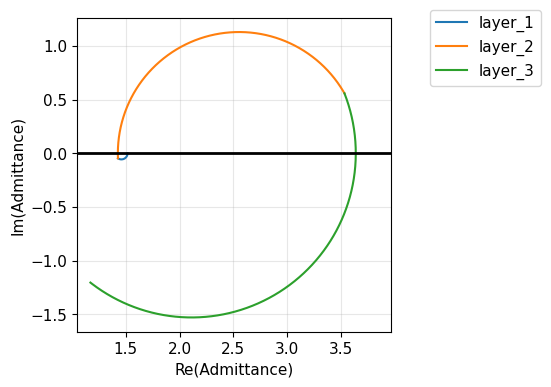

In [25]:
stack = pocal.pocal(three_layer, 0, 400, 800, 2, 600, False, None)
stack.admittance(savefile=False, savefig=False)
plt.show()


Compare a well-matched AR coating with a high-reflector — the endpoints tell the story.


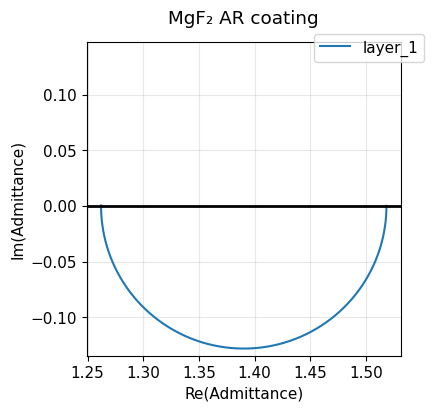

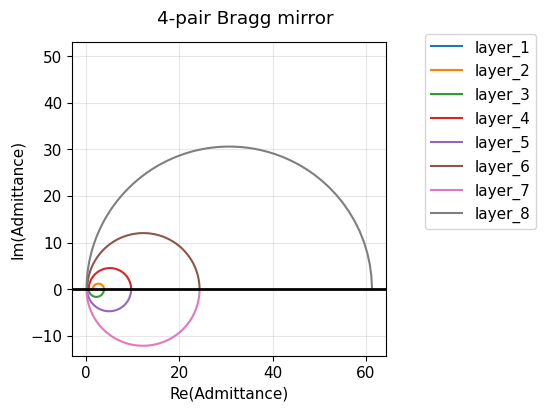

In [26]:
for path, optical, title in [(ar1, True, 'MgF₂ AR coating'),
                             ('bragg_4.txt', True, '4-pair Bragg mirror')]:
    stack = pocal.pocal(path, 0, 500, 600, 5, 550, optical, None)
    stack.admittance(savefile=False, savefig=False)
    plt.suptitle(title, y=1.02)
    plt.show()


---
# 11. Electric field inside the stack

Standing waves form inside a multilayer. Where the field peaks, absorption and laser damage
are worst — so field engineering matters for high-power optics. POCAL evaluates

$$E=\sqrt{\frac{2\,T\,I_{inc}}{\eta_{inc}}}$$

and plots it against optical distance from the medium, in full-wave optical thickness units,
assuming $I_{inc}=1\ \mathrm{W/m^2}$.


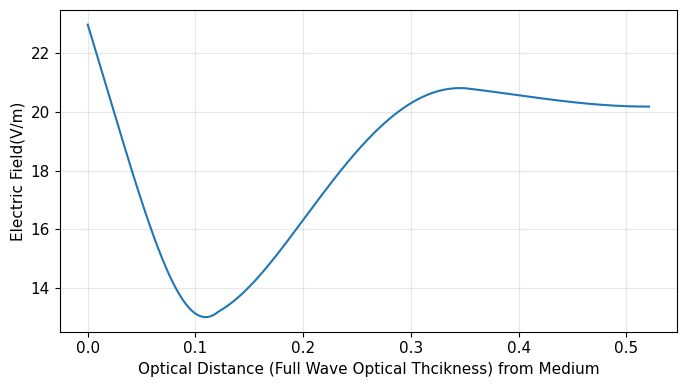

In [27]:
stack = pocal.pocal(three_layer, 0, 400, 800, 2, 600, False, None)
stack.electricField(savefile=False, savefig=False)
plt.show()


The same calculation for a Bragg mirror shows the characteristic decay — light penetrates only
the first few pairs, which is exactly why adding more of them stops helping.


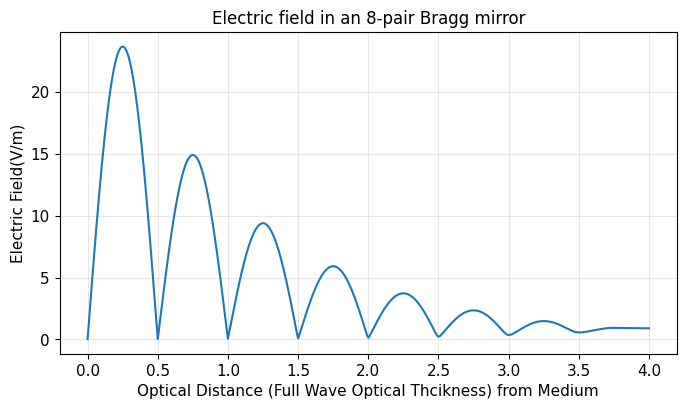

In [28]:
stack = pocal.pocal('bragg_8.txt', 0, 500, 600, 5, 550, True, None)
stack.electricField(savefile=False, savefig=False)
plt.title('Electric field in an 8-pair Bragg mirror')
plt.show()


---
# 12. Colour analysis

Dichroic filters and decorative coatings are specified by **colour**, not by a spectrum. POCAL
converts a spectrum into CIE tristimulus values by weighting it with a standard illuminant
$S(\lambda)$ and the colour-matching functions $\bar x, \bar y, \bar z$:

$$X=\frac{\int S(\lambda)\,\rho(\lambda)\,\bar x(\lambda)\,d\lambda}
{\int S(\lambda)\,\bar y(\lambda)\,d\lambda},
\qquad x=\frac{X}{X+Y+Z},\quad y=\frac{Y}{X+Y+Z}$$

Illuminants available: **A** (incandescent, 2856 K), **D65** (daylight, 6504 K), **E** (equal
energy). Observers: **CIE 1931** (2°) and **CIE 1964** (10°).

## 12.1 The built-in call

```python
stack.s_polarizationcolor('reflectance',
                          observer_type='CIE_1931',
                          illuminant_type='D65',
                          color_space='XYZ')   # or 'xyY', 'LAB', 'LUV'
```

> ⚠️ This method opens an **OpenCV window** to display the chromaticity diagram, which blocks
> until you close it and does not work on headless machines or in cloud notebooks. The cells
> below reproduce the same calculation in pure NumPy so it runs anywhere.

## 12.2 Illuminants and observers


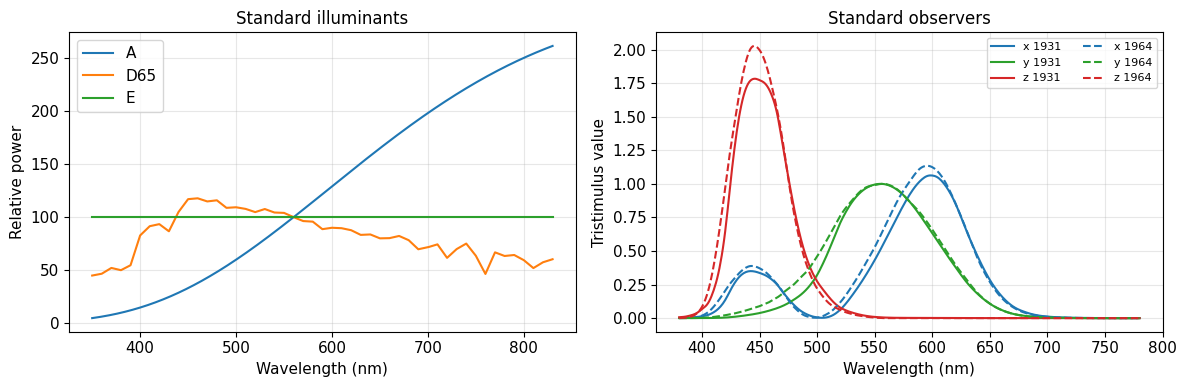

In [29]:
cmf1931 = np.loadtxt('cmf1931.txt')
cmf1964 = np.loadtxt('cmf1964.txt')
illuminants = {'A': np.loadtxt('a.txt'), 'D65': np.loadtxt('d65.txt'), 'E': np.loadtxt('e.txt')}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, data in illuminants.items():
    m = (data[:, 0] >= 350) & (data[:, 0] <= 830)
    ax1.plot(data[m, 0], data[m, 1], label=name)
ax1.set(xlabel='Wavelength (nm)', ylabel='Relative power', title='Standard illuminants')
ax1.legend()

for cmf, style, tag in [(cmf1931, '-', '1931'), (cmf1964, '--', '1964')]:
    m = (cmf[:, 0] >= 380) & (cmf[:, 0] <= 780)
    for col, colour, comp in [(1, 'tab:blue', 'x'), (2, 'tab:green', 'y'), (3, 'tab:red', 'z')]:
        ax2.plot(cmf[m, 0], cmf[m, col], style, color=colour, label=f'{comp} {tag}')
ax2.set(xlabel='Wavelength (nm)', ylabel='Tristimulus value', title='Standard observers')
ax2.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 12.3 Spectrum → colour


In [30]:
def spectrum_to_xyz(wavelength, percent, observer='CIE_1931', illuminant='D65'):
    """CIE tristimulus values for a reflectance/transmittance spectrum given in %."""
    cmf = cmf1931 if observer == 'CIE_1931' else cmf1964
    S = illuminants[illuminant]

    lo = max(wavelength.min(), cmf[:, 0].min(), S[:, 0].min())
    hi = min(wavelength.max(), cmf[:, 0].max(), S[:, 0].max())
    grid = np.arange(lo, hi + 1, 1.0)

    rho = np.interp(grid, wavelength, percent)
    xb, yb, zb = (np.interp(grid, cmf[:, 0], cmf[:, i]) for i in (1, 2, 3))
    Sg = np.interp(grid, S[:, 0], S[:, 1])

    denom = np.trapezoid(Sg * yb, grid)
    X, Y, Z = (np.trapezoid(Sg * rho * c, grid) / denom for c in (xb, yb, zb))
    total = X + Y + Z
    return X, Y, Z, X / total, Y / total


# Cross-check against Table 1 of the paper: 3-layer design, 40°, s-pol reflectance
w, R = spectrum(three_layer, 40, 'reflectance', 's', lo=400, hi=800, step=2, ref=600)

print(f"{'observer':<10} {'illum':<6} {'X':>8} {'Y':>8}   {'paper X':>8} {'paper Y':>8}")
print('-' * 56)
paper = {('CIE_1931', 'A'): (32.06, 30.80), ('CIE_1931', 'D65'): (29.38, 31.84),
         ('CIE_1931', 'E'): (30.58, 31.60), ('CIE_1964', 'A'): (32.66, 30.98),
         ('CIE_1964', 'D65'): (29.51, 32.19), ('CIE_1964', 'E'): (30.80, 31.94)}
for observer in ['CIE_1931', 'CIE_1964']:
    for illum in ['A', 'D65', 'E']:
        X, Y, Z, x, y = spectrum_to_xyz(w, R, observer, illum)
        px, py = paper[(observer, illum)]
        print(f'{observer:<10} {illum:<6} {X:>8.2f} {Y:>8.2f}   {px:>8.2f} {py:>8.2f}')


observer   illum         X        Y    paper X  paper Y
--------------------------------------------------------
CIE_1931   A         32.10    30.80      32.06    30.80
CIE_1931   D65       29.35    31.79      29.38    31.84
CIE_1931   E         30.55    31.57      30.58    31.60
CIE_1964   A         32.69    30.96      32.66    30.98
CIE_1964   D65       29.46    32.13      29.51    32.19
CIE_1964   E         30.77    31.89      30.80    31.94


## 12.4 Chromaticity of a design family

Sweeping a layer thickness walks the reflected colour around the chromaticity diagram — this is
the interference colour of an oil film or a soap bubble, computed exactly.


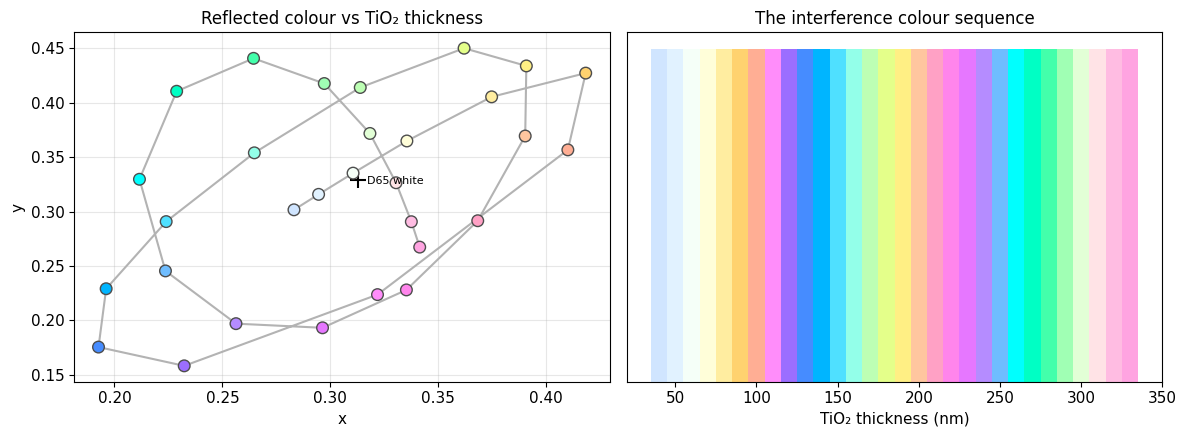

In [31]:
thicknesses = np.arange(40, 340, 10)
points, colours = [], []

for d in thicknesses:
    path = write_stack('_sweep.txt', [('Air', 0), ('TiO2', float(d)), ('Glass', 0)])
    w, R = spectrum(path, 0, 'reflectance', lo=400, hi=800, step=5)
    X, Y, Z, x, y = spectrum_to_xyz(w, R, 'CIE_1931', 'D65')
    points.append((x, y))

    # rough sRGB preview of the reflected colour
    M = np.array([[3.2406, -1.5372, -0.4986],
                  [-0.9689, 1.8758, 0.0415],
                  [0.0557, -0.2040, 1.0570]])
    rgb = M @ (np.array([X, Y, Z]) / 100)
    rgb = np.clip(rgb, 0, None)
    rgb = rgb / rgb.max() if rgb.max() > 0 else rgb
    rgb = np.where(rgb <= 0.0031308, 12.92 * rgb, 1.055 * rgb ** (1 / 2.4) - 0.055)
    colours.append(np.clip(rgb, 0, 1))

points = np.array(points)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(points[:, 0], points[:, 1], '-', color='0.7', zorder=1)
ax1.scatter(points[:, 0], points[:, 1], c=colours, s=70, edgecolor='0.3', zorder=2)
ax1.scatter([0.3127], [0.3290], marker='+', s=120, color='k')
ax1.text(0.317, 0.325, 'D65 white', fontsize=8)
ax1.set(xlabel='x', ylabel='y', title='Reflected colour vs TiO₂ thickness')

ax2.bar(thicknesses, np.ones(len(thicknesses)), width=10, color=colours)
ax2.set(xlabel='TiO₂ thickness (nm)', yticks=[], title='The interference colour sequence')
ax2.grid(False)
plt.tight_layout()
plt.show()


---
# 13. Refinement — automatic optimization

Given a target spectrum, POCAL adjusts every layer thickness (materials and order stay fixed)
to minimise

$$f(x)=\sqrt{\frac{\sum_i\left(T_{algo}(x,\lambda_i)-T_{target}(\lambda_i)\right)^2}{\sum_i i}}$$

using SciPy's Nelder–Mead simplex. For non-normal incidence it optimizes the **mean of s and p**.

Three things to set up:

1. a file called **`target.txt`** — wavelength in column 1, target % in column 2
2. `refinement_type` set to `'reflectance'` or `'transmittance'` when constructing the object
3. a **tolerance** passed to `refinement()` — larger is faster but coarser

The result is written to `refined_prescription.txt`.

## 13.1 The paper's example — a reflectance step

Target: 0 % reflectance below 800 nm, 30 % above 850 nm.


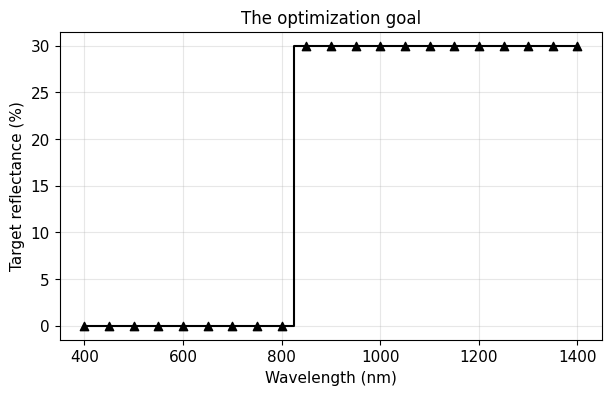

In [32]:
wl_target = np.arange(400, 1401, 50)
target = np.where(wl_target <= 800, 0.0, 30.0)
np.savetxt('target.txt', np.c_[wl_target, target], fmt='%g', delimiter='\t')

plt.step(wl_target, target, where='mid', color='k')
plt.scatter(wl_target, target, marker='^', color='k', zorder=3)
plt.xlabel('Wavelength (nm)'); plt.ylabel('Target reflectance (%)')
plt.title('The optimization goal')
plt.show()


Now run it. This takes roughly **10–30 seconds** — every simplex step re-runs the full spectral
calculation in both polarizations, so runtime scales with the number of wavelength points.
Use a coarse `resolution` while exploring.


Optimization terminated successfully.
         Current function value: 11.454361
         Iterations: 194
         Function evaluations: 316
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 11.454361388707422
             x: [ 0.000e+00  1.613e+02  1.318e+02  1.615e+02  0.000e+00]
           nit: 194
          nfev: 316
 final_simplex: (array([[ 0.000e+00,  1.613e+02, ...,  1.615e+02,
                         0.000e+00],
                       [ 0.000e+00,  1.608e+02, ...,  1.613e+02,
                         0.000e+00],
                       ...,
                       [ 0.000e+00,  1.611e+02, ...,  1.618e+02,
                         0.000e+00],
                       [ 0.000e+00,  1.607e+02, ...,  1.610e+02,
                         0.000e+00]]), array([ 1.145e+01,  1.145e+01,  1.145e+01,  1.145e+01,
                        1.145e+01,  1.145e+01]))
Computational time (s) =  30.204465627670288

Elapsed: 30.7 s


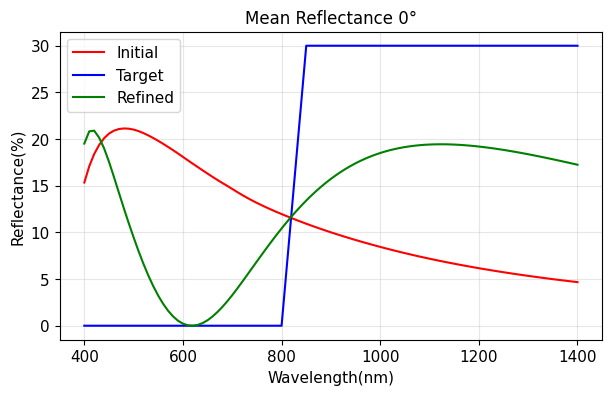

In [33]:
import time

start = time.time()
job = pocal.pocal(three_layer, 0, 400, 1400, 10, 600, False, 'reflectance')
job.refinement(10)          # 10 = tolerance
print(f'\nElapsed: {time.time() - start:.1f} s')


## 13.2 Before and after


Refined design:

Glass	0.0
SiO2	161.3015160474174
TiO2	131.75315397663127
SiO2	161.5468226903538
Glass	0.0



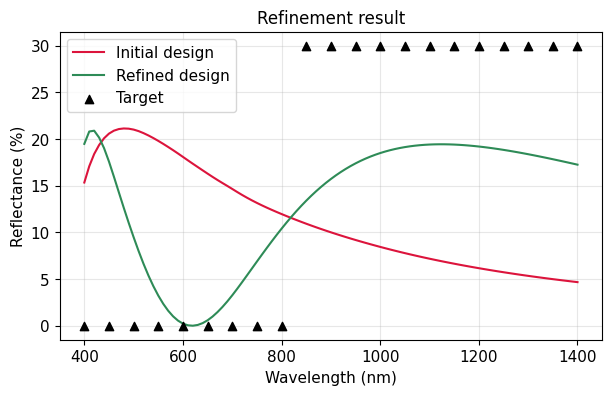

RMS error before : 20.552 %
RMS error after  : 11.454 %


In [34]:
print('Refined design:\n')
print(open('refined_prescription.txt').read())

w, R_before = spectrum(three_layer, 0, 'reflectance', lo=400, hi=1400, step=10, ref=600)
w, R_after = spectrum('refined_prescription.txt', 0, 'reflectance',
                      lo=400, hi=1400, step=10, ref=600)

plt.plot(w, R_before, color='crimson', label='Initial design')
plt.plot(w, R_after, color='seagreen', label='Refined design')
plt.scatter(wl_target, target, marker='^', color='k', zorder=3, label='Target')
plt.xlabel('Wavelength (nm)'); plt.ylabel('Reflectance (%)')
plt.title('Refinement result')
plt.legend()
plt.show()

rms = lambda R: np.sqrt(np.mean((np.interp(wl_target, w, R) - target) ** 2))
print(f'RMS error before : {rms(R_before):.3f} %')
print(f'RMS error after  : {rms(R_after):.3f} %')


## 13.3 Tolerance and local minima

Nelder–Mead finds a **local** minimum, so the starting design matters and different tolerances
land in different places. The paper makes this point explicitly: POCAL and Essential Macleod
reach comparable spectra from very different thickness sets. Treat refinement as a polisher of
a sensible starting design, not a global search.


In [35]:
results = {}
for tol in [50, 10, 1]:
    start = time.time()
    job = pocal.pocal(three_layer, 0, 400, 1400, 20, 600, False, 'reflectance')
    job.refinement(tol)
    plt.close('all')
    design = np.genfromtxt('refined_prescription.txt', dtype='str')
    w, R = spectrum('refined_prescription.txt', 0, 'reflectance',
                    lo=400, hi=1400, step=20, ref=600)
    results[tol] = (design[1:-1, 1].astype(float), rms(R), time.time() - start)

print(f"{'tol':>5} {'RMS %':>9} {'time s':>8}   thicknesses (nm)")
print('-' * 62)
for tol, (thick, err, dt) in results.items():
    pretty = '  '.join(f'{t:7.2f}' for t in thick)
    print(f'{tol:>5} {err:>9.3f} {dt:>8.1f}   {pretty}')


Optimization terminated successfully.
         Current function value: 12.778472
         Iterations: 71
         Function evaluations: 125
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 12.778472217514597
             x: [ 0.000e+00  6.248e-01  1.282e+02  1.602e+02  3.198e-06]
           nit: 71
          nfev: 125
 final_simplex: (array([[ 0.000e+00,  6.248e-01, ...,  1.602e+02,
                         3.198e-06],
                       [ 0.000e+00,  6.228e-01, ...,  1.595e+02,
                         3.260e-06],
                       ...,
                       [ 0.000e+00,  7.446e-01, ...,  1.597e+02,
                         2.772e-06],
                       [ 0.000e+00,  7.293e-01, ...,  1.594e+02,
                         3.215e-06]]), array([ 1.278e+01,  1.278e+01,  1.278e+01,  1.278e+01,
                        1.278e+01,  1.278e+01]))
Computational time (s) =  5.570275545120239
Optimization terminated successfu

---
# 14. Validation

Independent checks against results that are known in closed form. These are worth re-running
after any change to the library.

## 14.1 An index-matched interface must be invisible

Glass on identical glass has no physical interface, so $T = 100\%$ at **every** angle and
wavelength.


In [36]:
matched = write_stack('index_matched.txt', [('Glass', 0), ('Glass', 0)])

print(f"{'angle':>7} {'s-pol T %':>26} {'p-pol T %':>26}")
print('-' * 62)
worst = 0.0
for angle in [0, 15, 30, 45, 60, 75, 85]:
    _, Ts = spectrum(matched, angle, 'transmittance', 's', lo=450, hi=750, step=50)
    _, Tp = spectrum(matched, angle, 'transmittance', 'p', lo=450, hi=750, step=50)
    worst = max(worst, abs(Ts - 100).max(), abs(Tp - 100).max())
    print(f'{angle:>7} {Ts.min():>12.7f}–{Ts.max():<13.7f} '
          f'{Tp.min():>12.7f}–{Tp.max():<13.7f}')

print(f'\nWorst deviation from 100 %: {worst:.2e} percentage points')
print('PASS' if worst < 1e-6 else 'FAIL')


  angle                  s-pol T %                  p-pol T %
--------------------------------------------------------------
      0  100.0000000–100.0000000    100.0000000–100.0000000  
     15  100.0000000–100.0000000    100.0000000–100.0000000  
     30  100.0000000–100.0000000    100.0000000–100.0000000  
     45  100.0000000–100.0000000    100.0000000–100.0000000  
     60  100.0000000–100.0000000    100.0000000–100.0000000  
     75  100.0000000–100.0000000    100.0000000–100.0000000  
     85  100.0000000–100.0000000    100.0000000–100.0000000  

Worst deviation from 100 %: 1.71e-13 percentage points
PASS


## 14.2 Fresnel coefficients at a bare interface

For a single boundary the answer is analytic:
$T_s = \dfrac{4\eta_1\eta_2}{(\eta_1+\eta_2)^2}$ with $\eta=N\cos\theta$ (s) or
$N/\cos\theta$ (p).


In [37]:
probe = pocal.pocal(bare, 0, 450, 750, 50, 550, False, None)
n_glass = probe.search_from_nr_k_generator(probe.nr_k_array, 'Glass')[0]
waves = probe.wave_spacing

print(f"{'angle':>6} {'pol':>4} {'POCAL T %':>12} {'Fresnel T %':>13} {'diff':>12}")
print('-' * 52)
worst = 0.0
for angle in [0, 20, 40, 60, 75]:
    th = np.radians(angle)
    q1 = np.cos(th)                                   # n=1 in air
    q2 = np.sqrt(n_glass ** 2 - np.sin(th) ** 2)
    for pol in ['s', 'p']:
        if pol == 's':
            e1, e2 = q1, q2
        else:
            e1, e2 = 1.0 / q1, n_glass ** 2 / q2
        expected = 100 * 4 * e1 * e2 / (e1 + e2) ** 2
        _, T = spectrum(bare, angle, 'transmittance', pol, lo=450, hi=750, step=50)
        diff = np.abs(T - expected).max()
        worst = max(worst, diff)
        print(f'{angle:>6} {pol:>4} {T[0]:>12.6f} {expected[0]:>13.6f} {diff:>12.2e}')

print(f'\nWorst disagreement: {worst:.2e} percentage points')
print('PASS' if worst < 1e-6 else 'FAIL')


 angle  pol    POCAL T %   Fresnel T %         diff
----------------------------------------------------
     0    s    95.672757     95.672757     4.26e-14
     0    p    95.672757     95.672757     4.26e-14
    20    s    94.920860     94.920860     2.84e-14
    20    p    96.369482     96.369482     7.11e-14
    40    s    91.753287     91.753287     4.26e-14
    40    p    98.411185     98.411185     2.84e-14
    60    s    81.475407     81.475407     2.84e-14
    60    p    99.854312     99.854312     5.68e-14
    75    s    58.994037     58.994037     1.42e-14
    75    p    89.475138     89.475138     4.26e-14

Worst disagreement: 7.11e-14 percentage points
PASS


## 14.3 Total internal reflection is total

Past the critical angle the transmitted wave is evanescent and carries no power, so $T$ must
vanish and $R$ must be exactly 100 %.


In [38]:
probe = pocal.pocal(tir, 0, 450, 750, 50, 550, False, None)
n_glass = probe.search_from_nr_k_generator(probe.nr_k_array, 'Glass')[0]
theta_c = np.degrees(np.arcsin(1.0 / n_glass))
print(f'Critical angle spans {theta_c.min():.3f}° to {theta_c.max():.3f}° across 450–750 nm\n')

print(f"{'angle':>7} {'max T %':>12} {'min R %':>12}")
print('-' * 34)
worst_T, worst_R = 0.0, 100.0
for angle in [theta_c.max() + 0.5, 45, 55, 70, 85]:
    _, T = spectrum(tir, angle, 'transmittance', 's', lo=450, hi=750, step=50)
    _, R = spectrum(tir, angle, 'reflectance', 's', lo=450, hi=750, step=50)
    worst_T = max(worst_T, T.max()); worst_R = min(worst_R, R.min())
    print(f'{angle:>7.2f} {T.max():>12.3e} {R.min():>12.6f}')

print(f'\nLargest leaked T: {worst_T:.2e} %   smallest R: {worst_R:.6f} %')
print('PASS' if worst_T < 1e-6 and abs(worst_R - 100) < 1e-6 else 'FAIL')


Critical angle spans 40.965° to 41.412° across 450–750 nm

  angle      max T %      min R %
----------------------------------
  41.91    6.356e-10   100.000000
  45.00    3.270e-10   100.000000
  55.00    1.920e-10   100.000000
  70.00    1.099e-10   100.000000
  85.00    2.826e-11   100.000000

Largest leaked T: 6.36e-10 %   smallest R: 100.000000 %
PASS


> **Note on the numbers.** Residual transmission lands around $10^{-10}$ %, not exactly zero.
> That floor comes from spline interpolation of the tabulated $k$ values, which leaves
> $k \sim 10^{-13}$ rather than a hard zero — it is numerical noise, roughly twelve orders of
> magnitude below anything physically meaningful.


## 14.4 A quarter-wave stack peaks where theory says

For $N$ pairs the peak reflectance has a closed form. Agreement confirms both the layer
bookkeeping and the optical-thickness conversion.


In [39]:
probe = pocal.pocal('bragg_4.txt', 0, 540, 560, 10, 550, True, None)
idx = probe.wave_spacing == 550
nH = probe.search_from_nr_k_generator(probe.nr_k_array, 'TiO2')[0][idx][0]
nL = probe.search_from_nr_k_generator(probe.nr_k_array, 'SiO2')[0][idx][0]
nS = probe.search_from_nr_k_generator(probe.nr_k_array, 'Glass')[0][idx][0]
print(f'At 550 nm:  nH(TiO2) = {nH:.4f}   nL(SiO2) = {nL:.4f}   nS(Glass) = {nS:.4f}\n')

print(f"{'pairs':>6} {'POCAL R %':>12} {'theory R %':>12} {'diff':>10}")
print('-' * 44)
worst = 0.0
for pairs in [1, 2, 4, 6, 8, 12]:
    ratio = nS * (nH / nL) ** (2 * pairs)
    expected = 100 * ((1 - ratio) / (1 + ratio)) ** 2
    w, R = spectrum(f'bragg_{pairs}.txt', 0, 'reflectance',
                    lo=540, hi=560, step=10, ref=550, optical=True)
    got = R[w == 550][0]
    worst = max(worst, abs(got - expected))
    print(f'{pairs:>6} {got:>12.5f} {expected:>12.5f} {abs(got - expected):>10.4f}')

print(f'\nWorst disagreement: {worst:.4f} percentage points')
print('PASS' if worst < 0.1 else 'FAIL')


At 550 nm:  nH(TiO2) = 2.3178   nL(SiO2) = 1.4599   nS(Glass) = 1.5185

 pairs    POCAL R %   theory R %       diff
--------------------------------------------
     1     34.30130     34.30562     0.0043
     2     65.94623     65.96097     0.0147
     4     93.65445     93.68186     0.0274
     6     98.94791     98.97807     0.0302
     8     99.80784     99.83845     0.0306
    12     99.96529     99.99599     0.0307

Worst disagreement: 0.0307 percentage points
PASS


---
# 15. Quick reference

## Constructor

```python
stack = pocal.pocal(prescription, angle_in_deg, min_wave, max_wave,
                    resolution, ref_wave, opt_thick, refinement_type)
```

| Argument | Meaning |
|----------|---------|
| `prescription` | path to the two-column layer file |
| `angle_in_deg` | incidence angle, measured inside the immersing medium |
| `min_wave`, `max_wave` | wavelength range in nm |
| `resolution` | spacing between sample points, nm |
| `ref_wave` | reference wavelength — used by optical thickness, admittance, electric field |
| `opt_thick` | `True` = column 2 is optical thickness, `False` = physical nm |
| `refinement_type` | `None`, `'reflectance'` or `'transmittance'` |

## Methods

| Call | Returns | Notes |
|------|---------|-------|
| `s_polarization(label, savefile, savefig)` | `(wavelength, values)` for R/T/A, else `None` | draws a plot |
| `p_polarization(label, savefile, savefig)` | same | same |
| `admittance(savefile, savefig)` | `None` | uses `ref_wave` |
| `electricField(savefile, savefig)` | `None` | uses `ref_wave` |
| `s_polarizationcolor(...)` / `p_polarizationcolor(...)` | prints values | ⚠️ opens an OpenCV window |
| `refinement(tolerance)` | `None` | writes `refined_prescription.txt` |

## `label` values

`'reflectance'`, `'transmittance'`, `'absorbance'`, `'reflected_phase_shift'`,
`'transmitted_phase_shift'`, `'GD_ref'`, `'GDD_ref'`, `'GD_trans'`, `'GDD_trans'`

## Gotchas

- **Working directory matters.** `materialLibrary.json` and the colour/target files are read
  from the current directory by hardcoded name.
- **Only R, T and A return data.** The phase and GD/GDD labels plot but return `None`; use
  `savefile=True` to get those numbers as a `.txt`.
- **Unknown materials fail obscurely** with `ValueError: max() arg is an empty sequence`.
  Check spelling against the library.
- **Refinement cost scales with the wavelength grid.** Coarsen `resolution` while exploring.
- **Angles are inside the medium**, not in air, when the first line isn't air.

---

## Citing

> T. Fontanot, U. Bhaumik, R. Kishore, and Y. Meuret, "POCAL: a Python-based library to perform
> optical coating analysis and design," Optics Continuum **2**(4), 810–824 (2023).
